# Veri kaynakları ve birleşik tablo

Müşteri, araç, servis ve geri bildirim dosyaları yüklenip ilişkileri üzerinden birleştirilir. Ortaya çıkan tablo Excel dosyasına aktarılır.

In [1]:
from pathlib import Path
import pandas as pd

# İlişkiler: müşteriler (1) → araçlar (N) → servis kayıtları (N)
#                                         ↘ geri bildirimler (N)
veri_klasoru = Path('veri')
musteriler = pd.read_csv(veri_klasoru / 'musteriler.csv', encoding='utf-8')
araclar = pd.read_csv(veri_klasoru / 'araclar.csv', encoding='utf-8')
servis_kayitlari = pd.read_csv(veri_klasoru / 'servis_kayitlari.csv', encoding='utf-8')
geri_bildirimler = pd.read_csv(veri_klasoru / 'geri_bildirimler.csv', encoding='utf-8')

# Ham kayıtlar korunur; eşleşmeyen kayıt varsa sol birleşimle görünür kalır.
birlesik_veri = (
    musteriler
    .merge(araclar, on='musteri_id', how='left')
    .merge(servis_kayitlari, on='arac_id', how='left')
    .merge(geri_bildirimler, on='arac_id', how='left')
)

for ad, tablo in [('Müşteriler', musteriler), ('Araçlar', araclar),
                  ('Servis kayıtları', servis_kayitlari), ('Geri bildirimler', geri_bildirimler)]:
    print(f'{ad}: {len(tablo):,} satır')
print(f'Birleşik veri: {len(birlesik_veri):,} satır, {birlesik_veri.shape[1]} sütun')
print(f'Yinelenen müşteri kimliği: {musteriler.musteri_id.duplicated().sum():,}')
print(f'Yinelenen servis kimliği: {servis_kayitlari.kayit_id.duplicated().sum():,}')
print('Not: Aynı araca ait servis ve geri bildirimler eşleşirken satır çoğalır; bu tabloda doğrudan toplam almayın.')
birlesik_veri.head()

Müşteriler: 4,235 satır
Araçlar: 4,786 satır
Servis kayıtları: 32,770 satır
Geri bildirimler: 640 satır
Birleşik veri: 33,371 satır, 26 sütun
Yinelenen müşteri kimliği: 35
Yinelenen servis kimliği: 310
Not: Aynı araca ait servis ve geri bildirimler eşleşirken satır çoğalır; bu tabloda doğrudan toplam almayın.


,musteri_id,sehir,musteri_tipi,dogum_yili,ilk_temas_tarihi,kayit_kanali,crm_musteri_durumu,son_iletisim_notu,arac_id,marka,...,servis_tarihi,servis_tipi,servis_merkezi,km,tutar,memnuniyet_puani,geri_bildirim_id,tarih,kanal,metin
0,102288,Ankara,Bireysel,2002.0,2020-06-25,Bayi,Aktif,Kampanya bilgilendirmesi,502619,Marka-A,...,2023-02-25,Periyodik Bakım,SM-Kocaeli1,431.0,10139.78,NaN,NaN,NaN,NaN,NaN
1,102288,Ankara,Bireysel,2002.0,2020-06-25,Bayi,Aktif,Kampanya bilgilendirmesi,502619,Marka-A,...,2025-09-22,Periyodik Bakım,SM-Kadıköy,1819.0,7531.22,5.0,NaN,NaN,NaN,NaN
2,102288,Ankara,Bireysel,2002.0,2020-06-25,Bayi,Aktif,Kampanya bilgilendirmesi,502619,Marka-A,...,2024-02-29,Lastik/Balans,SM-Kadıköy,887.0,3492.59,5.0,NaN,NaN,NaN,NaN
3,102288,Ankara,Bireysel,2002.0,2020-06-25,Bayi,Aktif,Kampanya bilgilendirmesi,502619,Marka-A,...,2026-04-13,Arıza Onarım,SM-Maslak,2266.0,3249.20,4.0,NaN,NaN,NaN,NaN
4,102288,Ankara,Bireysel,2002.0,2020-06-25,Bayi,Aktif,Kampanya bilgilendirmesi,502619,Marka-A,...,02.12.2024,Periyodik Bakım,SM-Kocaeli1,1407.0,-9701.16,3.0,NaN,NaN,NaN,NaN


In [2]:
# Birleşik tabloyu Excel'e aktar. Serbest metinler formül olarak çalıştırılmaz.
cikti_dosyasi = Path('birlesik_veri.xlsx')
with pd.ExcelWriter(
    cikti_dosyasi,
    engine='xlsxwriter',
    engine_kwargs={'options': {'strings_to_formulas': False, 'strings_to_urls': False}},
) as yazici:
    birlesik_veri.to_excel(yazici, sheet_name='Birlesik Veri', index=False)
    sayfa = yazici.sheets['Birlesik Veri']
    sayfa.freeze_panes(1, 0)
    sayfa.autofilter(0, 0, len(birlesik_veri), len(birlesik_veri.columns) - 1)
print(f'Excel dosyası hazır: {cikti_dosyasi.resolve()}')


Excel dosyası hazır: /Users/mustafa/Downloads/aday_paketi/teslim/kod/birlesik_veri.xlsx


## Hata tespit fonksiyonu ve birleşik veri kontrolü

Bir pandas DataFrame üzerinde eksik değerleri, sütun biçimlerini, tarih formatlarını, sayısal sorunları ve tekrarları raporlayan fonksiyon tanımlanır; ardından birleşik veriye uygulanır.

In [3]:
from collections import Counter
from IPython.display import display
import re
import pandas as pd

def veri_hatalarini_incele(veri: pd.DataFrame, tablo_adi: str = 'veri') -> dict:
    """Bir DataFrame'in boş değer, biçim, tarih ve temel tutarlılık raporunu gösterir."""
    if not isinstance(veri, pd.DataFrame):
        raise TypeError('veri bir pandas DataFrame olmalı')

    # Konumsal indeks analizde güvenlidir; kullanıcıya örnekler özgün indeksle verilir.
    ozgun_indeks = pd.Series(veri.index.to_list())
    tablo = veri.reset_index(drop=True)

    def bos_maskesi(seri):
        bos = seri.isna()
        if pd.api.types.is_object_dtype(seri) or pd.api.types.is_string_dtype(seri):
            bos = bos | seri.astype('string').str.strip().eq('').fillna(False)
        return bos

    def deger_bicimi(deger):
        deger = str(deger).strip()
        if re.fullmatch(r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}', deger):
            return 'YYYY-MM-DD HH:MM:SS'
        if re.fullmatch(r'\d{4}-\d{2}-\d{2}', deger):
            return 'YYYY-MM-DD'
        if re.fullmatch(r'\d{2}/\d{2}/\d{4}', deger):
            return 'DD/MM/YYYY'
        if re.fullmatch(r'\d{2}\.\d{2}\.\d{4}', deger):
            return 'DD.MM.YYYY'
        if re.fullmatch(r'[+-]?\d+', deger):
            return 'tam sayı'
        if re.fullmatch(r'[+-]?\d+[.,]\d+', deger):
            return 'ondalık sayı'
        return 'metin/diğer'

    kolon_satirlari = []
    for kolon in tablo.columns:
        seri = tablo[kolon]
        bos = bos_maskesi(seri)
        bicimler = Counter(deger_bicimi(deger) for deger in seri[~bos])
        kolon_satirlari.append({
            'tablo': tablo_adi,
            'kolon': kolon,
            'pandas_tipi': str(seri.dtype),
            'NaN_sayi': int(seri.isna().sum()),
            'bos_metin_sayi': int((bos & ~seri.isna()).sum()),
            'bos_sayi': int(bos.sum()),
            'bos_oran_%': round(100 * bos.mean(), 2) if len(tablo) else 0.0,
            'benzersiz_deger': int(seri[~bos].nunique()),
            'gorulen_bicimler': ', '.join(f'{ad}: {sayi}' for ad, sayi in bicimler.most_common()),
            'bos_ornek_indeksler': ozgun_indeks[bos].head(5).tolist(),
        })
    kolon_kalitesi = pd.DataFrame(kolon_satirlari, columns=[
        'tablo', 'kolon', 'pandas_tipi', 'NaN_sayi', 'bos_metin_sayi',
        'bos_sayi', 'bos_oran_%', 'benzersiz_deger',
        'gorulen_bicimler', 'bos_ornek_indeksler',
    ])
    print(f'SÜTUN ÖZETİ — {tablo_adi}')
    display(kolon_kalitesi)

    tarih_bicimleri = [
        ('YYYY-MM-DD HH:MM:SS', r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}', '%Y-%m-%d %H:%M:%S'),
        ('YYYY-MM-DD', r'\d{4}-\d{2}-\d{2}', '%Y-%m-%d'),
        ('DD/MM/YYYY', r'\d{2}/\d{2}/\d{4}', '%d/%m/%Y'),
        ('DD.MM.YYYY', r'\d{2}\.\d{2}\.\d{4}', '%d.%m.%Y'),
    ]
    tarih_kolonlari = [kolon for kolon in tablo if kolon == 'tarih' or kolon.endswith('_tarihi')]
    tarih_format_satirlari = []
    tarih_ozet_satirlari = []
    tarih_serileri = {}
    for kolon in tarih_kolonlari:
        degerler = tablo[kolon].astype('string').str.strip()
        dolu = degerler.notna() & degerler.ne('').fillna(False)
        eslesen = pd.Series(False, index=tablo.index)
        cozulmus_seri = pd.Series(pd.NaT, index=tablo.index, dtype='datetime64[ns]')
        gecersiz_ornekler = []
        gorulen_format = 0
        gecersiz_sayi = 0
        for etiket, desen, tarih_formati in tarih_bicimleri:
            maske = dolu & degerler.str.fullmatch(desen).fillna(False)
            sayi = int(maske.sum())
            if not sayi:
                continue
            gorulen_format += 1
            eslesen = eslesen | maske
            cozulmus = pd.to_datetime(degerler[maske], format=tarih_formati, errors='coerce')
            cozulmus_seri.loc[cozulmus.index] = cozulmus
            hatali = cozulmus.isna()
            gecersiz_sayi += int(hatali.sum())
            gecersiz_ornekler.extend(degerler[maske][hatali].head(3).tolist())
            tarih_format_satirlari.append({
                'tablo': tablo_adi, 'kolon': kolon, 'format': etiket,
                'sayi': sayi, 'gecersiz_tarih': int(hatali.sum()),
            })
        tanimsiz = degerler[dolu & ~eslesen]
        if len(tanimsiz):
            gecersiz_sayi += len(tanimsiz)
            gecersiz_ornekler.extend(tanimsiz.head(3).tolist())
            tarih_format_satirlari.append({
                'tablo': tablo_adi, 'kolon': kolon, 'format': 'TANIMSIZ',
                'sayi': len(tanimsiz), 'gecersiz_tarih': len(tanimsiz),
            })
        gecerli_tarihler = cozulmus_seri.dropna()
        tarih_ozet_satirlari.append({
            'tablo': tablo_adi, 'kolon': kolon,
            'bos': int((~dolu).sum()), 'farkli_format': gorulen_format,
            'gecersiz_tarih': gecersiz_sayi,
            'en_erken': gecerli_tarihler.min().date() if len(gecerli_tarihler) else None,
            'en_gec': gecerli_tarihler.max().date() if len(gecerli_tarihler) else None,
            'gecersiz_ornekler': gecersiz_ornekler[:5],
        })
        tarih_serileri[kolon] = cozulmus_seri

    tarih_format_ozeti = pd.DataFrame(tarih_format_satirlari, columns=[
        'tablo', 'kolon', 'format', 'sayi', 'gecersiz_tarih',
    ])
    tarih_kalitesi = pd.DataFrame(tarih_ozet_satirlari, columns=[
        'tablo', 'kolon', 'bos', 'farkli_format', 'gecersiz_tarih',
        'en_erken', 'en_gec', 'gecersiz_ornekler',
    ])
    print('TARİH FORMATLARI — her biçimin kayıt sayısı ve geçersiz tarih sayısı')
    display(tarih_format_ozeti)
    print('TARİH KALİTESİ — eksik/geçersiz tarihler ve aralıklar')
    display(tarih_kalitesi)

    sayisal_satirlar = []
    for kolon in ['dogum_yili', 'model_yili', 'ilk_km', 'km', 'tutar', 'memnuniyet_puani']:
        if kolon not in tablo:
            continue
        ham = tablo[kolon]
        sayi = pd.to_numeric(ham, errors='coerce')
        sayisal_satirlar.append({
            'tablo': tablo_adi, 'kolon': kolon,
            'sayiya_cevrilemeyen': int((~bos_maskesi(ham) & sayi.isna()).sum()),
            'negatif': int(sayi.lt(0).sum()),
            'en_kucuk': sayi.min(), 'medyan': sayi.median(),
            'yuzde_99': sayi.quantile(0.99), 'en_buyuk': sayi.max(),
        })
    sayisal_kalite = pd.DataFrame(sayisal_satirlar, columns=[
        'tablo', 'kolon', 'sayiya_cevrilemeyen', 'negatif',
        'en_kucuk', 'medyan', 'yuzde_99', 'en_buyuk',
    ])
    print('SAYISAL ALANLAR — dönüşüm hataları, negatifler ve uç değer aralıkları')
    display(sayisal_kalite)

    kontrol_satirlari = []
    kontrol_satirlari.append({
        'kontrol': f'{tablo_adi}: tamamen aynı satır',
        'sorunlu_satir': int(tablo.duplicated().sum()),
    })
    for kolon in ['musteri_id', 'arac_id']:
        if kolon in tablo:
            kontrol_satirlari.append({
                'kontrol': f'{tablo_adi}: boş {kolon}',
                'sorunlu_satir': int(bos_maskesi(tablo[kolon]).sum()),
            })
    if 'kayit_id' in tablo:
        dolu_kayit = ~bos_maskesi(tablo['kayit_id'])
        kontrol_satirlari.append({
            'kontrol': f'{tablo_adi}: yinelenen dolu kayit_id',
            'sorunlu_satir': int(tablo.loc[dolu_kayit, 'kayit_id'].duplicated().sum()),
        })
    for kolon in ['ilk_km', 'km', 'tutar']:
        if kolon in tablo:
            sayilar = pd.to_numeric(tablo[kolon], errors='coerce')
            kontrol_satirlari.append({
                'kontrol': f'{tablo_adi}: negatif {kolon}',
                'sorunlu_satir': int(sayilar.lt(0).sum()),
            })
    if 'memnuniyet_puani' in tablo:
        puan = pd.to_numeric(tablo['memnuniyet_puani'], errors='coerce')
        kontrol_satirlari.append({
            'kontrol': f'{tablo_adi}: 1–5 dışında memnuniyet_puani',
            'sorunlu_satir': int((puan.notna() & ~puan.between(1, 5)).sum()),
        })
    if {'satin_alma_tarihi', 'garanti_bitis_tarihi'} <= tarih_serileri.keys():
        kontrol_satirlari.append({
            'kontrol': f'{tablo_adi}: garanti bitişi satın almadan önce',
            'sorunlu_satir': int(tarih_serileri['garanti_bitis_tarihi'].lt(tarih_serileri['satin_alma_tarihi']).sum()),
        })
    if {'satin_alma_tarihi', 'servis_tarihi'} <= tarih_serileri.keys():
        kontrol_satirlari.append({
            'kontrol': f'{tablo_adi}: servis satın almadan önce',
            'sorunlu_satir': int(tarih_serileri['servis_tarihi'].lt(tarih_serileri['satin_alma_tarihi']).sum()),
        })
    if {'satin_alma_tarihi', 'tarih'} <= tarih_serileri.keys():
        kontrol_satirlari.append({
            'kontrol': f'{tablo_adi}: bildirim satın almadan önce (incele)',
            'sorunlu_satir': int(tarih_serileri['tarih'].lt(tarih_serileri['satin_alma_tarihi']).sum()),
        })
    veri_kontrolleri = pd.DataFrame(kontrol_satirlari, columns=['kontrol', 'sorunlu_satir'])
    print('GENEL VERİ KONTROLLERİ — 0 dışındaki sayılar incelenmeli')
    display(veri_kontrolleri)
    if 'kayit_id' in tablo:
        print(f"{tablo_adi}: boş kayit_id {int(bos_maskesi(tablo['kayit_id']).sum()):,} satır (tekrar kontrolünde korunur).")

    return {
        'kolon_kalitesi': kolon_kalitesi,
        'tarih_format_ozeti': tarih_format_ozeti,
        'tarih_kalitesi': tarih_kalitesi,
        'sayisal_kalite': sayisal_kalite,
        'veri_kontrolleri': veri_kontrolleri,
    }


In [4]:
birlesik_hata_raporu = veri_hatalarini_incele(birlesik_veri, tablo_adi='birlesik_veri')


SÜTUN ÖZETİ — birlesik_veri


,tablo,kolon,pandas_tipi,NaN_sayi,bos_metin_sayi,bos_sayi,bos_oran_%,benzersiz_deger,gorulen_bicimler,bos_ornek_indeksler
0,birlesik_veri,musteri_id,int64,0,0,0,0.00,4200,tam sayı: 33371,[]
1,birlesik_veri,sehir,str,0,0,0,0.00,21,metin/diğer: 33371,[]
2,birlesik_veri,musteri_tipi,str,0,0,0,0.00,2,metin/diğer: 33371,[]
3,birlesik_veri,dogum_yili,float64,736,0,736,2.21,52,ondalık sayı: 32635,"[240, 241, 242, 243, 244]"
4,birlesik_veri,ilk_temas_tarihi,str,0,0,0,0.00,1878,YYYY-MM-DD: 33371,[]
5,birlesik_veri,kayit_kanali,str,0,0,0,0.00,4,metin/diğer: 33371,[]
6,birlesik_veri,crm_musteri_durumu,str,0,0,0,0.00,3,metin/diğer: 33371,[]
7,birlesik_veri,son_iletisim_notu,str,12467,0,12467,37.36,7,metin/diğer: 20904,"[18, 19, 20, 21, 22]"
8,birlesik_veri,arac_id,int64,0,0,0,0.00,4786,tam sayı: 33371,[]
9,birlesik_veri,marka,str,0,0,0,0.00,3,metin/diğer: 33371,[]


TARİH FORMATLARI — her biçimin kayıt sayısı ve geçersiz tarih sayısı


,tablo,kolon,format,sayi,gecersiz_tarih
0,birlesik_veri,ilk_temas_tarihi,YYYY-MM-DD,33371,0
1,birlesik_veri,satin_alma_tarihi,YYYY-MM-DD,33371,0
2,birlesik_veri,garanti_bitis_tarihi,YYYY-MM-DD,33371,0
3,birlesik_veri,servis_tarihi,YYYY-MM-DD HH:MM:SS,1897,0
4,birlesik_veri,servis_tarihi,YYYY-MM-DD,23337,0
5,birlesik_veri,servis_tarihi,DD/MM/YYYY,4056,0
6,birlesik_veri,servis_tarihi,DD.MM.YYYY,4053,0
7,birlesik_veri,tarih,YYYY-MM-DD,4447,0


TARİH KALİTESİ — eksik/geçersiz tarihler ve aralıklar


...

SAYISAL ALANLAR — dönüşüm hataları, negatifler ve uç değer aralıkları


,tablo,kolon,sayiya_cevrilemeyen,negatif,en_kucuk,medyan,yuzde_99,en_buyuk
0,birlesik_veri,dogum_yili,0,0,1890.00,1980.00,2004.0000,2.021000e+03
1,birlesik_veri,model_yili,0,0,2013.00,2018.00,2025.0000,2.025000e+03
2,birlesik_veri,ilk_km,0,0,0.00,31.00,89.0000,1.150000e+02
3,birlesik_veri,km,0,43,-2976.00,1189.00,2913.5800,3.938000e+03
4,birlesik_veri,tutar,0,153,-47222.59,9905.47,41313.4324,2.886854e+06
5,birlesik_veri,memnuniyet_puani,0,0,1.00,4.00,5.0000,5.000000e+00


GENEL VERİ KONTROLLERİ — 0 dışındaki sayılar incelenmeli


,kontrol,sorunlu_satir
0,birlesik_veri: tamamen aynı satır,588
1,birlesik_veri: boş musteri_id,0
2,birlesik_veri: boş arac_id,0
3,birlesik_veri: yinelenen dolu kayit_id,883
4,birlesik_veri: negatif ilk_km,0
5,birlesik_veri: negatif km,43
6,birlesik_veri: negatif tutar,153
7,birlesik_veri: 1–5 dışında memnuniyet_puani,0
8,birlesik_veri: garanti bitişi satın almadan önce,0
9,birlesik_veri: servis satın almadan önce,0


birlesik_veri: boş kayit_id 28 satır (tekrar kontrolünde korunur).


# Temiz veri

Birleşik verinin kopyasında tarihler tek biçime getirilir, kullanılmayacak alanlar ve dolu kayıt kimliği tekrarları çıkarılır. Temizlikten sonraki veri kalite raporu yeniden üretilir.

In [5]:
from IPython.display import display

# Temiz veri: ham birleşik tablo ve kaynak CSV'ler korunur.
temiz_veri = birlesik_veri.drop(columns=[
    'son_iletisim_notu',
    'geri_bildirim_id', 'tarih', 'kanal', 'metin', "crm_musteri_durumu"
]).copy()

# Kaynakta görülen tarih biçimleri açıkça ayrıştırılır.
# Sonuç yalnızca YYYY-MM-DD metnidir; eksik tarihler eksik kalır.
tarih_bicimleri = [
    (r'\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}', '%Y-%m-%d %H:%M:%S'),
    (r'\d{4}-\d{2}-\d{2}', '%Y-%m-%d'),
    (r'\d{2}/\d{2}/\d{4}', '%d/%m/%Y'),
    (r'\d{2}\.\d{2}\.\d{4}', '%d.%m.%Y'),
]

def tarihi_standartlastir(seri):
    kaynak = seri.astype('string')
    sonuc = kaynak.copy()
    dolu = kaynak.notna() & kaynak.str.strip().ne('').fillna(False)
    eslesen = pd.Series(False, index=kaynak.index)
    for desen, bicim in tarih_bicimleri:
        maske = dolu & kaynak.str.fullmatch(desen).fillna(False)
        if maske.any():
            sonuc.loc[maske] = pd.to_datetime(
                kaynak.loc[maske], format=bicim, errors='raise'
            ).dt.strftime('%Y-%m-%d')
            eslesen = eslesen | maske
    bilinmeyen = dolu & ~eslesen
    if bilinmeyen.any():
        raise ValueError(f'Bilinmeyen tarih biçimi: {kaynak[bilinmeyen].head().tolist()}')
    return sonuc

for kolon in ['ilk_temas_tarihi', 'satin_alma_tarihi',
              'garanti_bitis_tarihi', 'servis_tarihi']:
    temiz_veri[kolon] = tarihi_standartlastir(temiz_veri[kolon])

# Sadece dolu kayit_id tekrarlarının sonraki satırlarını çıkar.
# Boş kayit_id satırları ve musteri_id tekrarları bu kuralla hedeflenmez.
kayit_dolu = (
    temiz_veri['kayit_id'].notna()
    & temiz_veri['kayit_id'].astype('string').str.strip().ne('').fillna(False)
)
tekrar_kayit = kayit_dolu & temiz_veri['kayit_id'].duplicated(keep='first')
temiz_veri = temiz_veri.loc[~tekrar_kayit].copy()

print(f'Temizlenmiş tablo: {len(temiz_veri):,} satır, {temiz_veri.shape[1]} sütun')
print(f'Dolu kayit_id tekrarı nedeniyle çıkarılan satır: {int(tekrar_kayit.sum()):,}')
print(f'Korunan boş kayit_id satırı: {int(temiz_veri.kayit_id.isna().sum()):,}')


Temizlenmiş tablo: 32,488 satır, 20 sütun
Dolu kayit_id tekrarı nedeniyle çıkarılan satır: 883
Korunan boş kayit_id satırı: 28


In [6]:
temiz_hata_raporu = veri_hatalarini_incele(temiz_veri, tablo_adi='temiz_veri')


SÜTUN ÖZETİ — temiz_veri


,tablo,kolon,pandas_tipi,NaN_sayi,bos_metin_sayi,bos_sayi,bos_oran_%,benzersiz_deger,gorulen_bicimler,bos_ornek_indeksler
0,temiz_veri,musteri_id,int64,0,0,0,0.00,4200,tam sayı: 32488,[]
1,temiz_veri,sehir,str,0,0,0,0.00,21,metin/diğer: 32488,[]
2,temiz_veri,musteri_tipi,str,0,0,0,0.00,2,metin/diğer: 32488,[]
3,temiz_veri,dogum_yili,float64,716,0,716,2.20,52,ondalık sayı: 31772,"[240, 241, 242, 243, 244]"
4,temiz_veri,ilk_temas_tarihi,string,0,0,0,0.00,1878,YYYY-MM-DD: 32488,[]
5,temiz_veri,kayit_kanali,str,0,0,0,0.00,4,metin/diğer: 32488,[]
6,temiz_veri,arac_id,int64,0,0,0,0.00,4786,tam sayı: 32488,[]
7,temiz_veri,marka,str,0,0,0,0.00,3,metin/diğer: 32488,[]
8,temiz_veri,model,str,0,0,0,0.00,8,metin/diğer: 32488,[]
9,temiz_veri,model_yili,int64,0,0,0,0.00,13,tam sayı: 32488,[]


TARİH FORMATLARI — her biçimin kayıt sayısı ve geçersiz tarih sayısı


,tablo,kolon,format,sayi,gecersiz_tarih
0,temiz_veri,ilk_temas_tarihi,YYYY-MM-DD,32488,0
1,temiz_veri,satin_alma_tarihi,YYYY-MM-DD,32488,0
2,temiz_veri,garanti_bitis_tarihi,YYYY-MM-DD,32488,0
3,temiz_veri,servis_tarihi,YYYY-MM-DD,32460,0


TARİH KALİTESİ — eksik/geçersiz tarihler ve aralıklar


...

SAYISAL ALANLAR — dönüşüm hataları, negatifler ve uç değer aralıkları


,tablo,kolon,sayiya_cevrilemeyen,negatif,en_kucuk,medyan,yuzde_99,en_buyuk
0,temiz_veri,dogum_yili,0,0,1890.00,1980.00,2004.000,2.021000e+03
1,temiz_veri,model_yili,0,0,2013.00,2018.00,2025.000,2.025000e+03
2,temiz_veri,ilk_km,0,0,0.00,31.00,89.000,1.150000e+02
3,temiz_veri,km,0,40,-2976.00,1189.00,2918.000,3.938000e+03
4,temiz_veri,tutar,0,150,-47222.59,9909.24,41327.647,2.886854e+06
5,temiz_veri,memnuniyet_puani,0,0,1.00,4.00,5.000,5.000000e+00


GENEL VERİ KONTROLLERİ — 0 dışındaki sayılar incelenmeli


,kontrol,sorunlu_satir
0,temiz_veri: tamamen aynı satır,1
1,temiz_veri: boş musteri_id,0
2,temiz_veri: boş arac_id,0
3,temiz_veri: yinelenen dolu kayit_id,0
4,temiz_veri: negatif ilk_km,0
5,temiz_veri: negatif km,40
6,temiz_veri: negatif tutar,150
7,temiz_veri: 1–5 dışında memnuniyet_puani,0
8,temiz_veri: garanti bitişi satın almadan önce,0
9,temiz_veri: servis satın almadan önce,0


temiz_veri: boş kayit_id 28 satır (tekrar kontrolünde korunur).


# Zaman pencereleri ve churn etiketleri

Servisler kesim tarihine göre özellik ve hedef dönemlerine ayrılır. Hedef döneminde servis kaydı bulunan müşteriler için churn=0, bulunmayanlar için churn=1 atanır.

In [7]:
# Servis satırlarını modelleme zamanına göre ayır; temiz_veri değişmez.
servis_tarihi_dt = pd.to_datetime(
    temiz_veri['servis_tarihi'], format='%Y-%m-%d', errors='raise'
)
ozellik_maskesi = servis_tarihi_dt.le(pd.Timestamp('2025-06-30'))
hedef_maskesi = servis_tarihi_dt.between(
    pd.Timestamp('2025-07-01'), pd.Timestamp('2026-06-30'), inclusive='both'
)
assert not (ozellik_maskesi & hedef_maskesi).any()

servis_ozellik = temiz_veri.loc[ozellik_maskesi].copy()
servis_hedef = temiz_veri.loc[hedef_maskesi].copy()
# Sonraki churn etiketinde servis_hedef yalnızca kayıt varlığı için okunur;
# hedef penceresindeki km ve tutar değerleri temizlenmez.

# Tarihi olmayan satırlar tanımlı iki pencereye girmez; sessizce atılmaz.
pencere_disi_satirlar = temiz_veri.loc[~(ozellik_maskesi | hedef_maskesi)].copy()

print(f'Özellik penceresi (<= 2025-06-30): {len(servis_ozellik):,} satır')
print(f'Hedef penceresi (2025-07-01 ... 2026-06-30): {len(servis_hedef):,} satır')
print(f'Pencere dışında tutulan satır: {len(pencere_disi_satirlar):,} '
      f'(tarihi boş: {int(pencere_disi_satirlar.servis_tarihi.isna().sum()):,})')
print(f'Hedefte korunan negatif KM kaydı: {int(servis_hedef.km.lt(0).sum()):,}')


Özellik penceresi (<= 2025-06-30): 25,061 satır
Hedef penceresi (2025-07-01 ... 2026-06-30): 7,399 satır
Pencere dışında tutulan satır: 28 (tarihi boş: 28)
Hedefte korunan negatif KM kaydı: 14


In [8]:
from IPython.display import display

# Hedef penceresinde en az bir servis satırı varsa müşteri churn=0'dır.
# km/tutar değerleri kullanılmaz; servis_hedef üzerinde değişiklik yapılmaz.
hedef_musteri_idleri = pd.Index(servis_hedef['musteri_id'].dropna().unique())
servis_ozellik = servis_ozellik.copy()
servis_ozellik['churn'] = (
    ~servis_ozellik['musteri_id'].isin(hedef_musteri_idleri)
).astype('int8')

# Her müşterinin tek etiketi ayrıca saklanır; servis_ozellik tüm satırları korur.
churn_etiketleri = (
    servis_ozellik[['musteri_id', 'churn']]
    .drop_duplicates(subset='musteri_id')
    .reset_index(drop=True)
)
assert not servis_ozellik.groupby('musteri_id')['churn'].nunique().gt(1).any()

print(f'Etiketlenen müşteri: {len(churn_etiketleri):,}')
print(f"churn=0 (hedefte servis var): {int(churn_etiketleri['churn'].eq(0).sum()):,} müşteri")
print(f"churn=1 (hedefte servis yok): {int(churn_etiketleri['churn'].eq(1).sum()):,} müşteri")
print('MÜŞTERİ DÜZEYİNDE CHURN ETİKETLERİ — ilk 10 kayıt')


Etiketlenen müşteri: 3,974
churn=0 (hedefte servis var): 3,316 müşteri
churn=1 (hedefte servis yok): 658 müşteri
MÜŞTERİ DÜZEYİNDE CHURN ETİKETLERİ — ilk 10 kayıt


## Özellik penceresi kalite kontrolü

Temizlik öncesindeki özellik dönemi, aynı veri kalite fonksiyonuyla kontrol edilir. Bu çıktı sonraki temizlik işlemleriyle karşılaştırma sağlar.

In [9]:
se= veri_hatalarini_incele(servis_ozellik, tablo_adi='servis_ozellik')


SÜTUN ÖZETİ — servis_ozellik


,tablo,kolon,pandas_tipi,NaN_sayi,bos_metin_sayi,bos_sayi,bos_oran_%,benzersiz_deger,gorulen_bicimler,bos_ornek_indeksler
0,servis_ozellik,musteri_id,int64,0,0,0,0.00,3974,tam sayı: 25061,[]
1,servis_ozellik,sehir,str,0,0,0,0.00,21,metin/diğer: 25061,[]
2,servis_ozellik,musteri_tipi,str,0,0,0,0.00,2,metin/diğer: 25061,[]
3,servis_ozellik,dogum_yili,float64,559,0,559,2.23,52,ondalık sayı: 24502,"[240, 241, 242, 243, 245]"
4,servis_ozellik,ilk_temas_tarihi,string,0,0,0,0.00,1853,YYYY-MM-DD: 25061,[]
5,servis_ozellik,kayit_kanali,str,0,0,0,0.00,4,metin/diğer: 25061,[]
6,servis_ozellik,arac_id,int64,0,0,0,0.00,4508,tam sayı: 25061,[]
7,servis_ozellik,marka,str,0,0,0,0.00,3,metin/diğer: 25061,[]
8,servis_ozellik,model,str,0,0,0,0.00,8,metin/diğer: 25061,[]
9,servis_ozellik,model_yili,int64,0,0,0,0.00,13,tam sayı: 25061,[]


TARİH FORMATLARI — her biçimin kayıt sayısı ve geçersiz tarih sayısı


,tablo,kolon,format,sayi,gecersiz_tarih
0,servis_ozellik,ilk_temas_tarihi,YYYY-MM-DD,25061,0
1,servis_ozellik,satin_alma_tarihi,YYYY-MM-DD,25061,0
2,servis_ozellik,garanti_bitis_tarihi,YYYY-MM-DD,25061,0
3,servis_ozellik,servis_tarihi,YYYY-MM-DD,25061,0


TARİH KALİTESİ — eksik/geçersiz tarihler ve aralıklar


...

SAYISAL ALANLAR — dönüşüm hataları, negatifler ve uç değer aralıkları


,tablo,kolon,sayiya_cevrilemeyen,negatif,en_kucuk,medyan,yuzde_99,en_buyuk
0,servis_ozellik,dogum_yili,0,0,1890.00,1980.0,2004.00,2.021000e+03
1,servis_ozellik,model_yili,0,0,2013.00,2018.0,2024.00,2.025000e+03
2,servis_ozellik,ilk_km,0,0,0.00,31.0,89.00,1.150000e+02
3,servis_ozellik,km,0,26,-2976.00,1012.0,2400.40,3.230000e+03
4,servis_ozellik,tutar,0,118,-47222.59,9883.7,41515.56,2.886854e+06
5,servis_ozellik,memnuniyet_puani,0,0,1.00,4.0,5.00,5.000000e+00


GENEL VERİ KONTROLLERİ — 0 dışındaki sayılar incelenmeli


,kontrol,sorunlu_satir
0,servis_ozellik: tamamen aynı satır,0
1,servis_ozellik: boş musteri_id,0
2,servis_ozellik: boş arac_id,0
3,servis_ozellik: yinelenen dolu kayit_id,0
4,servis_ozellik: negatif ilk_km,0
5,servis_ozellik: negatif km,26
6,servis_ozellik: negatif tutar,118
7,servis_ozellik: 1–5 dışında memnuniyet_puani,0
8,servis_ozellik: garanti bitişi satın almadan önce,0
9,servis_ozellik: servis satın almadan önce,0


servis_ozellik: boş kayit_id 0 satır (tekrar kontrolünde korunur).


# Özellik penceresinde servis temizliği

Yalnızca özellik penceresinde sıfır kayıt kimlikleri ve negatif KM satırları çıkarılır; boş ve negatif tutarlar aynı servis merkezi ve tipinin medyanıyla düzeltilir. Yapılan işlemler raporlanır ve sonuç yeniden kontrol edilir.

In [10]:
from IPython.display import display

# Yalnızca özellik penceresi işlenir; servis_hedef değişmez.
servis_ozellik_temiz = servis_ozellik.copy()

# Önce 3) kayit_id değeri 0 olan satırları çıkar.
sifir_kayit_id = pd.to_numeric(servis_ozellik_temiz['kayit_id'], errors='coerce').eq(0)
silinen_sifir_id = int(sifir_kayit_id.sum())
servis_ozellik_temiz = servis_ozellik_temiz.loc[~sifir_kayit_id].copy()

grup_kolonlari = ['servis_merkezi', 'servis_tipi']

# 1) Boş tutarı yalnızca aynı merkez + aynı tip grubundaki dolu tutarların
# medyanıyla doldur. Grup anahtarı veya grup medyanı yoksa boş değer korunur.
bos_tutar = servis_ozellik_temiz['tutar'].isna()
grup_medyan = servis_ozellik_temiz.groupby(grup_kolonlari)['tutar'].transform('median')
grup_ortalama = servis_ozellik_temiz.groupby(grup_kolonlari)['tutar'].transform('mean')
doldurulabilir = (
    bos_tutar
    & servis_ozellik_temiz[grup_kolonlari].notna().all(axis=1)
    & grup_medyan.notna()
)

tutar_doldurulanlar = servis_ozellik_temiz.loc[
    doldurulabilir,
    ['musteri_id', 'arac_id', 'kayit_id', *grup_kolonlari, 'tutar'],
].copy()
tutar_doldurulanlar.insert(0, 'kaynak_indeks', tutar_doldurulanlar.index)
tutar_doldurulanlar = tutar_doldurulanlar.rename(columns={'tutar': 'eski_tutar'})
tutar_doldurulanlar['grup_medyan'] = grup_medyan.loc[doldurulabilir].to_numpy()
tutar_doldurulanlar['grup_ortalama'] = grup_ortalama.loc[doldurulabilir].to_numpy()
tutar_doldurulanlar['medyan_eksi_ortalama'] = (
    tutar_doldurulanlar['grup_medyan'] - tutar_doldurulanlar['grup_ortalama']
)
tutar_doldurulanlar['yeni_tutar'] = tutar_doldurulanlar['grup_medyan']

tutar_doldurulamayanlar = servis_ozellik_temiz.loc[
    bos_tutar & ~doldurulabilir,
    ['musteri_id', 'arac_id', 'kayit_id', *grup_kolonlari, 'tutar'],
].copy()
tutar_doldurulamayanlar.insert(0, 'kaynak_indeks', tutar_doldurulamayanlar.index)
tutar_doldurulamayanlar['neden'] = 'Servis merkezi veya servis tipi boş'
tutar_doldurulamayanlar.loc[
    tutar_doldurulamayanlar[grup_kolonlari].notna().all(axis=1), 'neden'
] = 'Bu grupta dolu tutar yok'

# Doldurma için kullanılan gruplarda medyan ve aritmetik ortalama karşılaştırması.
servis_grup_ozeti = (
    servis_ozellik_temiz.groupby(grup_kolonlari)['tutar']
    .agg(['count', 'median', 'mean'])
    .rename(columns={
        'count': 'dolu_tutar_sayisi',
        'median': 'grup_medyan',
        'mean': 'grup_ortalama',
    })
    .reset_index()
)
servis_grup_ozeti['medyan_eksi_ortalama'] = (
    servis_grup_ozeti['grup_medyan'] - servis_grup_ozeti['grup_ortalama']
)
servis_ozellik_temiz.loc[doldurulabilir, 'tutar'] = grup_medyan.loc[doldurulabilir]

# 2) Negatif KM satırlarını çıkar.
negatif_km = pd.to_numeric(servis_ozellik_temiz['km'], errors='coerce').lt(0)
silinen_negatif_km = int(negatif_km.sum())
servis_ozellik_temiz = servis_ozellik_temiz.loc[~negatif_km].copy()

# 4) Veri sözlüğündeki doğum bilgisi olan dogum_yili sütununu çıkar.
servis_ozellik_temiz = servis_ozellik_temiz.drop(columns=['dogum_yili'])

# 5) Negatif tutarları aynı merkez + tip grubundaki geçerli tutarların medyanıyla doldur.
# Hatalı negatif değerler medyan ve ortalama hesabına katılmaz.
negatif_tutar = servis_ozellik_temiz['tutar'].lt(0)
gecerli_tutar = servis_ozellik_temiz['tutar'].where(servis_ozellik_temiz['tutar'].ge(0))
grup_istatistikleri = servis_ozellik_temiz.assign(gecerli_tutar=gecerli_tutar).groupby(
    grup_kolonlari
)['gecerli_tutar']
negatif_grup_medyan = grup_istatistikleri.transform('median')
negatif_grup_ortalama = grup_istatistikleri.transform('mean')
negatif_grup_sayi = grup_istatistikleri.transform('count')
negatif_doldurulabilir = negatif_tutar & negatif_grup_medyan.notna()

negatif_tutar_raporu = servis_ozellik_temiz.loc[
    negatif_doldurulabilir,
    ['musteri_id', 'arac_id', 'kayit_id', *grup_kolonlari, 'tutar'],
].copy()
negatif_tutar_raporu.insert(0, 'kaynak_indeks', negatif_tutar_raporu.index)
negatif_tutar_raporu = negatif_tutar_raporu.rename(columns={'tutar': 'eski_tutar'})
negatif_tutar_raporu['grup_gecerli_tutar_sayisi'] = negatif_grup_sayi.loc[negatif_doldurulabilir].to_numpy()
negatif_tutar_raporu['grup_medyan'] = negatif_grup_medyan.loc[negatif_doldurulabilir].to_numpy()
negatif_tutar_raporu['grup_ortalama'] = negatif_grup_ortalama.loc[negatif_doldurulabilir].to_numpy()
negatif_tutar_raporu['medyan_eksi_ortalama'] = (
    negatif_tutar_raporu['grup_medyan'] - negatif_tutar_raporu['grup_ortalama']
)
negatif_tutar_raporu['yeni_tutar'] = negatif_tutar_raporu['grup_medyan']

negatif_tutar_doldurulamayanlar = servis_ozellik_temiz.loc[
    negatif_tutar & ~negatif_doldurulabilir,
    ['musteri_id', 'arac_id', 'kayit_id', *grup_kolonlari, 'tutar'],
].copy()
servis_ozellik_temiz.loc[negatif_doldurulabilir, 'tutar'] = negatif_grup_medyan.loc[negatif_doldurulabilir]

# 6) Önceki rapordaki tekrar temiz_veri'deki tarihsiz satırlardadır.
# Her iki kopyayı yalnızca göster; hiçbir pencereden bu nedenle satır silme.
tekrar_eden_satirlar = temiz_veri.loc[
    temiz_veri.duplicated(keep=False)
].copy()
tekrar_eden_satirlar.insert(0, 'kaynak_indeks', tekrar_eden_satirlar.index)

print('SERVİS ÖZELLİK TEMİZLİĞİ — ÖZET')
print(f'Kalan kayıt: {len(servis_ozellik_temiz):,} | sütun: {servis_ozellik_temiz.shape[1]}')
print(f'Silinen kayit_id=0: {silinen_sifir_id:,} | silinen negatif KM: {silinen_negatif_km:,}')
print(f'Boş tutar doldurulan: {len(tutar_doldurulanlar):,} | doldurulamayan: {len(tutar_doldurulamayanlar):,}')
print(f'Negatif tutar düzeltilen: {len(negatif_tutar_raporu):,} | düzeltilemeyen: {len(negatif_tutar_doldurulamayanlar):,}')
print(f'Tamamen aynı fazladan satır: {int(servis_ozellik_temiz.duplicated().sum()):,}')

print('\nNEGATİF TUTAR DÜZELTMELERİ — geçerli grup tutarlarının medyanı kullanıldı')
if negatif_tutar_raporu.empty:
    print('Negatif tutar bulunmadı.')
else:
    display(negatif_tutar_raporu[
        ['kaynak_indeks', 'musteri_id', 'kayit_id', *grup_kolonlari,
         'eski_tutar', 'grup_gecerli_tutar_sayisi', 'grup_medyan',
         'grup_ortalama', 'medyan_eksi_ortalama', 'yeni_tutar']
    ])

if not negatif_tutar_doldurulamayanlar.empty:
    print('\nDÜZELTİLEMEYEN NEGATİF TUTARLAR — grupta geçerli tutar yok')
    display(negatif_tutar_doldurulamayanlar)

if not tutar_doldurulanlar.empty:
    print('\nBOŞ (NaN) TUTAR DOLDURMALARI')
    display(tutar_doldurulanlar)
if not tutar_doldurulamayanlar.empty:
    print('\nDOLDURULAMAYAN BOŞ (NaN) TUTARLAR')
    display(tutar_doldurulamayanlar)

if not tekrar_eden_satirlar.empty:
    print('\nTEKRAR EDEN KAYIT — temiz_veri içindeki tarihsiz satırlar')
    display(tekrar_eden_satirlar)

# Negatif KM temizliği tüm özellik satırlarını sildiyse müşteri etiketi
# churn_etiketleri içinde yine korunur; modelleme kohortu için görünür kıl.
ozellik_kaydi_kalmayan_musteriler = churn_etiketleri.loc[
    ~churn_etiketleri['musteri_id'].isin(servis_ozellik_temiz['musteri_id'])
].copy()
print(f'\nÖzellik tablosunda satırı kalmayan müşteri: {len(ozellik_kaydi_kalmayan_musteriler):,}')
if not ozellik_kaydi_kalmayan_musteriler.empty:
    display(ozellik_kaydi_kalmayan_musteriler)


SERVİS ÖZELLİK TEMİZLİĞİ — ÖZET
Kalan kayıt: 25,035 | sütun: 20
Silinen kayit_id=0: 0 | silinen negatif KM: 26
Boş tutar doldurulan: 0 | doldurulamayan: 0
Negatif tutar düzeltilen: 118 | düzeltilemeyen: 0
Tamamen aynı fazladan satır: 0

NEGATİF TUTAR DÜZELTMELERİ — geçerli grup tutarlarının medyanı kullanıldı


,kaynak_indeks,musteri_id,kayit_id,servis_merkezi,servis_tipi,eski_tutar,grup_gecerli_tutar_sayisi,grup_medyan,grup_ortalama,medyan_eksi_ortalama,yeni_tutar
4,4,102288,17711.0,SM-Kocaeli1,Periyodik Bakım,-9701.16,1409,9554.21,10772.367350,-1218.157350,9554.21
787,787,103962,30518.0,SM-Kadıköy,Periyodik Bakım,-13576.44,2875,9433.85,9821.544483,-387.694483,9433.85
1125,1125,100267,2130.0,SM-Kadıköy,Periyodik Bakım,-7693.56,2875,9433.85,9821.544483,-387.694483,9433.85
1623,1623,102498,19228.0,SM-Bursa1,Periyodik Bakım,-12815.23,1692,9408.10,10135.530844,-727.430844,9408.10
1675,1675,101082,8317.0,SM-Maslak,Periyodik Bakım,-5882.96,3738,9507.23,10507.269292,-1000.039292,9507.23
...,...,...,...,...,...,...,...,...,...,...,...
31985,31985,103838,29516.0,SM-Kadıköy,Periyodik Bakım,-10933.43,2875,9433.85,9821.544483,-387.694483,9433.85
32092,32092,100968,7433.0,SM-İzmir1,Periyodik Bakım,-13009.55,1978,9392.06,10166.541928,-774.481928,9392.06
32645,32645,100271,2167.0,SM-Antalya1,Periyodik Bakım,-11536.89,1553,9597.68,10062.683382,-465.003382,9597.68
32742,32742,101235,9468.0,SM-Maslak,Periyodik Bakım,-14994.38,3738,9507.23,10507.269292,-1000.039292,9507.23



TEKRAR EDEN KAYIT — temiz_veri içindeki tarihsiz satırlar


,kaynak_indeks,musteri_id,sehir,musteri_tipi,dogum_yili,ilk_temas_tarihi,kayit_kanali,arac_id,marka,model,...,satin_alma_tarihi,garanti_bitis_tarihi,ilk_km,kayit_id,servis_tarihi,servis_tipi,servis_merkezi,km,tutar,memnuniyet_puani
19025,19025,101291,İstanbul,Bireysel,2000.0,2017-03-06,Bayi,501468,Marka-A,A-SUV,...,2025-05-15,2028-05-14,33,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
19026,19026,101291,İstanbul,Bireysel,2000.0,2017-03-06,Bayi,501468,Marka-A,A-SUV,...,2025-05-15,2028-05-14,33,NaN,<NA>,NaN,NaN,NaN,NaN,NaN



Özellik tablosunda satırı kalmayan müşteri: 1


,musteri_id,churn
3468,102429,0


In [11]:
veri_hatalarini_incele(servis_ozellik_temiz, tablo_adi='servis_ozellik_temiz')


SÜTUN ÖZETİ — servis_ozellik_temiz


,tablo,kolon,pandas_tipi,NaN_sayi,bos_metin_sayi,bos_sayi,bos_oran_%,benzersiz_deger,gorulen_bicimler,bos_ornek_indeksler
0,servis_ozellik_temiz,musteri_id,int64,0,0,0,0.00,3973,tam sayı: 25035,[]
1,servis_ozellik_temiz,sehir,str,0,0,0,0.00,21,metin/diğer: 25035,[]
2,servis_ozellik_temiz,musteri_tipi,str,0,0,0,0.00,2,metin/diğer: 25035,[]
3,servis_ozellik_temiz,ilk_temas_tarihi,string,0,0,0,0.00,1853,YYYY-MM-DD: 25035,[]
4,servis_ozellik_temiz,kayit_kanali,str,0,0,0,0.00,4,metin/diğer: 25035,[]
5,servis_ozellik_temiz,arac_id,int64,0,0,0,0.00,4507,tam sayı: 25035,[]
6,servis_ozellik_temiz,marka,str,0,0,0,0.00,3,metin/diğer: 25035,[]
7,servis_ozellik_temiz,model,str,0,0,0,0.00,8,metin/diğer: 25035,[]
8,servis_ozellik_temiz,model_yili,int64,0,0,0,0.00,13,tam sayı: 25035,[]
9,servis_ozellik_temiz,satin_alma_tarihi,string,0,0,0,0.00,2691,YYYY-MM-DD: 25035,[]


TARİH FORMATLARI — her biçimin kayıt sayısı ve geçersiz tarih sayısı


,tablo,kolon,format,sayi,gecersiz_tarih
0,servis_ozellik_temiz,ilk_temas_tarihi,YYYY-MM-DD,25035,0
1,servis_ozellik_temiz,satin_alma_tarihi,YYYY-MM-DD,25035,0
2,servis_ozellik_temiz,garanti_bitis_tarihi,YYYY-MM-DD,25035,0
3,servis_ozellik_temiz,servis_tarihi,YYYY-MM-DD,25035,0


TARİH KALİTESİ — eksik/geçersiz tarihler ve aralıklar


...

,tablo,kolon,sayiya_cevrilemeyen,negatif,en_kucuk,medyan,yuzde_99,en_buyuk
0,servis_ozellik_temiz,model_yili,0,0,2013.0,2018.00,2024.000,2.025000e+03
1,servis_ozellik_temiz,ilk_km,0,0,0.0,31.00,89.000,1.150000e+02
2,servis_ozellik_temiz,km,0,0,28.0,1013.00,2400.660,3.230000e+03
3,servis_ozellik_temiz,tutar,0,0,0.0,9899.41,41517.861,2.886854e+06
4,servis_ozellik_temiz,memnuniyet_puani,0,0,1.0,4.00,5.000,5.000000e+00


GENEL VERİ KONTROLLERİ — 0 dışındaki sayılar incelenmeli


,kontrol,sorunlu_satir
0,servis_ozellik_temiz: tamamen aynı satır,0
1,servis_ozellik_temiz: boş musteri_id,0
2,servis_ozellik_temiz: boş arac_id,0
3,servis_ozellik_temiz: yinelenen dolu kayit_id,0
4,servis_ozellik_temiz: negatif ilk_km,0
5,servis_ozellik_temiz: negatif km,0
6,servis_ozellik_temiz: negatif tutar,0
7,servis_ozellik_temiz: 1–5 dışında memnuniyet_p...,0
8,servis_ozellik_temiz: garanti bitişi satın alm...,0
9,servis_ozellik_temiz: servis satın almadan önce,0


servis_ozellik_temiz: boş kayit_id 0 satır (tekrar kontrolünde korunur).


{'kolon_kalitesi':                    tablo                 kolon pandas_tipi  NaN_sayi  \
 0   servis_ozellik_temiz            musteri_id       int64         0   
 1   servis_ozellik_temiz                 sehir         str         0   
 2   servis_ozellik_temiz          musteri_tipi         str         0   
 3   servis_ozellik_temiz      ilk_temas_tarihi      string         0   
 4   servis_ozellik_temiz          kayit_kanali         str         0   
 5   servis_ozellik_temiz               arac_id       int64         0   
 6   servis_ozellik_temiz                 marka         str         0   
 7   servis_ozellik_temiz                 model         str         0   
 8   servis_ozellik_temiz            model_yili       int64         0   
 9   servis_ozellik_temiz     satin_alma_tarihi      string         0   
 10  servis_ozellik_temiz  garanti_bitis_tarihi      string         0   
 11  servis_ozellik_temiz                ilk_km       int64         0   
 12  servis_ozellik_temiz        

# Müşteri düzeyinde feature tablosu

Kesim tarihine kadar bilinen müşteri, araç, servis ve anket bilgileri müşteri başına tek satırda özetlenir. Burada üretilen tablo hem keşifsel analiz hem de model girdisi seçimi için kullanılır.

In [12]:
from IPython.display import display
import numpy as np

# Kesim tarihi ve eğitim kohortu: özellik penceresinde etiketi tanımlanmış müşteriler.
kesim_tarihi = pd.Timestamp('2025-06-30')
# Aylık oranlarda gözlem, veri içindeki ilk özellik servisinden önce başlayamaz.
veri_ilk_servis_tarihi = pd.to_datetime(
    servis_ozellik['servis_tarihi'], format='%Y-%m-%d', errors='raise'
).min()
assert pd.notna(veri_ilk_servis_tarihi) and veri_ilk_servis_tarihi <= kesim_tarihi
cohort = churn_etiketleri[['musteri_id', 'churn']].copy()
assert cohort['musteri_id'].is_unique

# Negatif KM temizliği nedeniyle bütün özellik servisleri silinen müşteriyi kaydet.
# Kaynakta müşteri adı bulunmadığından kimliği ve çıkarılma nedeni saklanır.
feature_dislanan_musteriler = ozellik_kaydi_kalmayan_musteriler[['musteri_id', 'churn']].copy()
orijinal_servisler = servis_ozellik.loc[
    servis_ozellik['musteri_id'].isin(feature_dislanan_musteriler['musteri_id'])
]
negatif_km_sayisi = orijinal_servisler.groupby('musteri_id')['km'].agg(
    ozellik_servis_sayisi='size',
    negatif_km_servis_sayisi=lambda x: int(x.lt(0).sum()),
)
feature_dislanan_musteriler = feature_dislanan_musteriler.merge(
    negatif_km_sayisi.reset_index(), on='musteri_id', how='left', validate='one_to_one'
)
assert feature_dislanan_musteriler['ozellik_servis_sayisi'].eq(
    feature_dislanan_musteriler['negatif_km_servis_sayisi']
).all()
feature_dislanan_musteriler['neden'] = 'Tüm özellik servisleri negatif KM nedeniyle silindi'
feature_dislanan_musteriler.to_csv(
    'feature_dislanan_musteriler.csv', index=False, encoding='utf-8-sig'
)
cohort = cohort.loc[
    ~cohort['musteri_id'].isin(feature_dislanan_musteriler['musteri_id'])
].copy()

# Müşteri kaynağındaki aynı kimliğe ait tamamen özdeş satırları tekilleştir.
musteri_kaynagi = musteriler.drop_duplicates().copy()
assert musteri_kaynagi['musteri_id'].is_unique
musteri_kaynagi['ilk_temas_tarihi'] = pd.to_datetime(
    tarihi_standartlastir(musteri_kaynagi['ilk_temas_tarihi']), format='%Y-%m-%d'
)
musteri_feature = cohort[['musteri_id']].merge(
    musteri_kaynagi[['musteri_id', 'ilk_temas_tarihi', 'musteri_tipi', 'kayit_kanali', 'dogum_yili']],
    on='musteri_id', how='left', validate='one_to_one'
)
musteri_feature['musteri_ilk_temas_suresi_ay'] = (
    (kesim_tarihi - musteri_feature['ilk_temas_tarihi']).dt.days / 30.44
).clip(lower=1)
# İlk temas süresi müşteri yaşı değildir; kronolojik yaş yalnızca bireysel müşteri için anlamlıdır.
dogum_yili = pd.to_numeric(musteri_feature['dogum_yili'], errors='coerce')
musteri_feature['musteri_yasi_yil'] = (
    kesim_tarihi.year - dogum_yili
).where(musteri_feature['musteri_tipi'].eq('Bireysel'))

musteri_feature['musteri_tipi_Bireysel'] = musteri_feature['musteri_tipi'].eq('Bireysel').astype('int8')
for deger, kolon in [
    ('Bayi', 'kayit_kanali_Bayi'), ('Web', 'kayit_kanali_Web'),
    ('Çağrı Merkezi', 'kayit_kanali_Cagri_Merkezi'),
    ('Mobil Uygulama', 'kayit_kanali_Mobil_Uygulama'),
]:
    musteri_feature[kolon] = musteri_feature['kayit_kanali'].eq(deger).astype('int8')
musteri_feature = musteri_feature.drop(columns=['ilk_temas_tarihi', 'musteri_tipi', 'kayit_kanali', 'dogum_yili'])

# Araçlar önce araç düzeyinde hazırlanır; kesim sonrası satın alınanlar dışarıda kalır.
arac_feature = araclar.copy()
assert arac_feature['arac_id'].is_unique
arac_feature['satin_alma_tarihi'] = pd.to_datetime(
    tarihi_standartlastir(arac_feature['satin_alma_tarihi']), format='%Y-%m-%d'
)
arac_feature['garanti_bitis_tarihi'] = pd.to_datetime(
    tarihi_standartlastir(arac_feature['garanti_bitis_tarihi']), format='%Y-%m-%d'
)
gelecek_arac_sayisi = int(arac_feature['satin_alma_tarihi'].gt(kesim_tarihi).sum())
arac_feature = arac_feature.loc[
    arac_feature['satin_alma_tarihi'].le(kesim_tarihi)
    & arac_feature['musteri_id'].isin(cohort['musteri_id'])
].copy()
# Araç gözlemi, satın alma ve veri başlangıcından geç olan tarihte başlar.
arac_gozlem_baslangici = arac_feature['satin_alma_tarihi'].clip(lower=veri_ilk_servis_tarihi)
arac_feature['gozlem_suresi_ay'] = (
    (kesim_tarihi - arac_gozlem_baslangici).dt.days / 30.44
).clip(lower=1)
assert arac_feature['gozlem_suresi_ay'].gt(0).all()
arac_feature['aktif_garanti'] = arac_feature['garanti_bitis_tarihi'].gt(kesim_tarihi).astype('int8')
for marka in ['A', 'B', 'C']:
    arac_feature[f'marka_{marka}_sayisi'] = arac_feature['marka'].eq(f'Marka-{marka}').astype('int8')
# Model, araç düzeyinde one-hot; müşteri düzeyinde herhangi bir araçta var mı?
model_gostergeleri = pd.get_dummies(arac_feature['model'], prefix='model', dtype='int8')
model_kolonlari = model_gostergeleri.columns.tolist()
arac_feature = pd.concat([arac_feature, model_gostergeleri], axis=1)

# Temizlenmiş özellik servislerini yalnızca arac_id üzerinden araç sahibine bağla.
servis_feature = servis_ozellik_temiz[
    ['kayit_id', 'arac_id', 'servis_tarihi', 'servis_tipi', 'servis_merkezi', 'km', 'tutar', 'memnuniyet_puani']
].merge(arac_feature[['arac_id', 'musteri_id', 'gozlem_suresi_ay']], on='arac_id', how='inner', validate='many_to_one')
servis_feature['servis_tarihi'] = pd.to_datetime(servis_feature['servis_tarihi'], format='%Y-%m-%d')
assert servis_feature['servis_tarihi'].le(kesim_tarihi).all()
assert len(servis_feature) == len(servis_ozellik_temiz)
assert servis_feature['kayit_id'].is_unique

# Merkez, servis düzeyinde one-hot; önce araçta, ardından müşteride var/yok.
merkez_gostergeleri = pd.get_dummies(
    servis_feature['servis_merkezi'], prefix='servis_merkezi', dtype='int8'
)
merkez_kolonlari = merkez_gostergeleri.columns.tolist()
arac_merkez_gostergeleri = (
    pd.concat([servis_feature[['arac_id']], merkez_gostergeleri], axis=1)
    .groupby('arac_id')[merkez_kolonlari].max().reset_index()
)
arac_feature = arac_feature.merge(
    arac_merkez_gostergeleri, on='arac_id', how='left', validate='one_to_one'
)
arac_feature[merkez_kolonlari] = arac_feature[merkez_kolonlari].fillna(0).astype('int8')

# Araç başına son geçerli KM ve aylık KM hızı.
son_km = (
    servis_feature.loc[servis_feature['km'].notna() & servis_feature['km'].ge(0)]
    .sort_values(['arac_id', 'servis_tarihi', 'kayit_id'])
    .drop_duplicates('arac_id', keep='last')[['arac_id', 'km', 'servis_tarihi']]
    .rename(columns={'km': 'son_gecerli_km', 'servis_tarihi': 'son_km_tarihi'})
)
arac_feature = arac_feature.merge(son_km, on='arac_id', how='left', validate='one_to_one')
# Okuma ve süre aynı tarihte biter; kesim gününe kadar geçen süre kullanılmaz.
km_gozlem_gun = (
    arac_feature['son_km_tarihi'] - arac_feature['satin_alma_tarihi']
).dt.days
assert km_gozlem_gun.dropna().gt(0).all()
arac_feature['aylik_km_hizi'] = (
    (arac_feature['son_gecerli_km'] - arac_feature['ilk_km']) / (km_gozlem_gun / 30.44)
)

# Aralık yalnızca ardışık servisler arasındadır; satın alma tarihi diziye girmez.
servis_cizelgesi = servis_feature[[
    'arac_id', 'kayit_id', 'servis_tarihi'
]].sort_values(['arac_id', 'servis_tarihi', 'kayit_id']).copy()
servis_cizelgesi['aralik_gun'] = (
    servis_cizelgesi.groupby('arac_id')['servis_tarihi'].diff().dt.days
)
arac_ritim = servis_cizelgesi.groupby('arac_id').agg(
    ort_servis_araligi_gun=('aralik_gun', 'mean'),
    servis_araligi_std=('aralik_gun', 'std'),
    servis_sayisi=('servis_tarihi', 'size'),
    son_servis_tarihi=('servis_tarihi', 'max'),
).reset_index()
# Önce 2+ servisli araçların gerçek aralık medyanını bul; sonra tek servislileri doldur.
gecikme_payda_medyani_gun = arac_ritim.loc[
    arac_ritim['servis_sayisi'].ge(2), 'ort_servis_araligi_gun'
].median()
assert pd.notna(gecikme_payda_medyani_gun) and gecikme_payda_medyani_gun > 0
tek_servisli_arac = arac_ritim['servis_sayisi'].eq(1)
arac_ritim['ort_servis_araligi_gun'] = (
    arac_ritim['ort_servis_araligi_gun'].fillna(gecikme_payda_medyani_gun)
)
# Son servisten geçen süreyi aracın kendi ardışık servis aralığına böl.
arac_ritim['kisisel_servis_ritmi'] = (
    (kesim_tarihi - arac_ritim['son_servis_tarihi']).dt.days /
    arac_ritim['ort_servis_araligi_gun']
)
arac_ritim['gecikme_orani'] = (
    (kesim_tarihi - arac_ritim['son_servis_tarihi']).dt.days / gecikme_payda_medyani_gun
)
arac_feature = arac_feature.merge(
    arac_ritim[['arac_id', 'ort_servis_araligi_gun', 'servis_araligi_std',
                'servis_sayisi', 'gecikme_orani', 'kisisel_servis_ritmi']],
    on='arac_id', how='left', validate='one_to_one'
)

# Sıfır veya tek servisli araçlarda bireysel aralık gözlenmemiştir.
arac_feature['yetersiz_servis_gecmisi_var_mi'] = (
    arac_feature['servis_sayisi'].fillna(0).lt(2).astype('int8')
)
arac_toplam = arac_feature.groupby('musteri_id').agg(
    arac_sayisi=('arac_id', 'count'), ort_model_yili=('model_yili', 'mean'),
    son_arac_alis_tarihi=('satin_alma_tarihi', 'max'),
    aktif_garanti_var_mi=('aktif_garanti', 'max'), ort_ilk_km=('ilk_km', 'mean'),
    ort_aylik_km_hizi=('aylik_km_hizi', 'mean'),
    marka_A_sayisi=('marka_A_sayisi', 'sum'),
    marka_B_sayisi=('marka_B_sayisi', 'sum'),
    marka_C_sayisi=('marka_C_sayisi', 'sum'),
    gecikme_orani=('gecikme_orani', 'max'),
    yetersiz_servis_gecmisi_var_mi=('yetersiz_servis_gecmisi_var_mi', 'max'),
    **{kolon: (kolon, 'max') for kolon in [*model_kolonlari, *merkez_kolonlari]},
)
arac_toplam['son_arac_alis_gun'] = (kesim_tarihi - arac_toplam.pop('son_arac_alis_tarihi')).dt.days
# Son satın alınan araç: eşit satın alma tarihlerinde arac_id ile deterministik seçim.
son_alinan_arac = (
    arac_feature.sort_values(['musteri_id', 'satin_alma_tarihi', 'arac_id'])
    .drop_duplicates('musteri_id', keep='last')
    .set_index('musteri_id')
)
arac_toplam['son_alinan_arac_model_yili'] = son_alinan_arac['model_yili']
arac_toplam['son_alinan_arac_ilk_km'] = son_alinan_arac['ilk_km']
assert arac_toplam['son_arac_alis_gun'].equals((kesim_tarihi - son_alinan_arac['satin_alma_tarihi'].reindex(arac_toplam.index)).dt.days)

# Churn müşteri bazında herhangi bir servisin varlığına dayanır. Ritim için de
# müşterinin en son gerçek servisine gelen aracı seç; daha eski araçtaki max oranı alma.
son_musteri_servisi = (
    servis_feature.sort_values(['musteri_id', 'servis_tarihi', 'kayit_id'])
    .drop_duplicates('musteri_id', keep='last')
    .set_index('musteri_id')[['arac_id', 'servis_tarihi']]
)
arac_toplam['kisisel_servis_ritmi'] = son_musteri_servisi['arac_id'].map(
    arac_ritim.set_index('arac_id')['kisisel_servis_ritmi']
)
arac_toplam['recency_gun'] = (
    kesim_tarihi - son_musteri_servisi['servis_tarihi']
).dt.days

# Servis sayısıyla ağırlıklı araç ritmi; std yalnızca 3+ servisli araçlardan gelir.
for kolon in ['ort_servis_araligi_gun', 'servis_araligi_std']:
    gecerli = arac_feature[kolon].notna() & arac_feature['servis_sayisi'].gt(0)
    agirlikli = (arac_feature.loc[gecerli, kolon] * arac_feature.loc[gecerli, 'servis_sayisi'])
    pay = agirlikli.groupby(arac_feature.loc[gecerli, 'musteri_id']).sum()
    payda = arac_feature.loc[gecerli].groupby('musteri_id')['servis_sayisi'].sum()
    arac_toplam[kolon] = pay / payda

# Tek servisli araçta std; hiç servisi kalmayan müşteride aralık tanımsızdır.
# İstenen müşteri seviyesinde dolu çıktı için mevcut müşteri medyanı kullanılır.
for kolon in ['ort_servis_araligi_gun', 'servis_araligi_std']:
    medyan = arac_toplam[kolon].median()
    assert pd.notna(medyan)
    arac_toplam[kolon] = arac_toplam[kolon].fillna(medyan)

# Servis türlerini ve müşteri toplamlarını, araç sahipliği üzerinden hesapla.
tip_kolonlari = {
    'Periyodik Bakım': 'periyodik_bakim_sayisi',
    'Arıza Onarım': 'ariza_onarim_sayisi',
    'Kaporta/Boya': 'kaporta_boya_sayisi',
    'Lastik/Balans': 'lastik_balans_sayisi',
}
for tip, kolon in tip_kolonlari.items():
    servis_feature[kolon] = servis_feature['servis_tipi'].eq(tip).astype('int8')
# Her servis, bağlı olduğu aracın gözlenebilir ay sayısına göre ağırlıklandırılır.
musteri_aylik_oranlari = pd.DataFrame({
    'musteri_id': servis_feature['musteri_id'],
    'aylik_servis_sikligi': 1 / servis_feature['gozlem_suresi_ay'],
    'aylik_ariza_sikligi': (
        servis_feature['ariza_onarim_sayisi'] / servis_feature['gozlem_suresi_ay']
    ),
}).groupby('musteri_id').sum()
servis_toplam = servis_feature.groupby('musteri_id').agg(
    toplam_servis_sayisi=('kayit_id', 'count'),
    toplam_harcama=('tutar', 'sum'),
    **{kolon: (kolon, 'sum') for kolon in tip_kolonlari.values()},
)
musteri_feature_tablosu = (
    musteri_feature.merge(arac_toplam.reset_index(), on='musteri_id', how='left', validate='one_to_one')
    .merge(servis_toplam.reset_index(), on='musteri_id', how='left', validate='one_to_one')
)
sayim_kolonlari = ['toplam_servis_sayisi', 'toplam_harcama', *tip_kolonlari.values()]
musteri_feature_tablosu[sayim_kolonlari] = musteri_feature_tablosu[sayim_kolonlari].fillna(0)
# En sık ziyaret edilen servis merkezindeki kayıtların tüm servis kayıtlarına oranı.
merkez_ziyaret_sayisi = servis_feature.groupby(['musteri_id', 'servis_merkezi']).size()
en_sik_merkez_ziyaret_sayisi = merkez_ziyaret_sayisi.groupby(level='musteri_id').max()
merkez_bagliligi = en_sik_merkez_ziyaret_sayisi.div(
    musteri_feature_tablosu.set_index('musteri_id')['toplam_servis_sayisi'].replace(0, np.nan)
)
musteri_feature_tablosu['servis_merkezi_bagliligi'] = (
    musteri_feature_tablosu['musteri_id'].map(merkez_bagliligi)
)
# Kesim tarihi dahil son 180 takvim günündeki servis etkinliği.
son_180_gun_baslangic = kesim_tarihi - pd.Timedelta(days=179)
son_180_gun_servisleri = servis_feature.loc[
    servis_feature['servis_tarihi'].between(son_180_gun_baslangic, kesim_tarihi)
].groupby('musteri_id').size()
musteri_feature_tablosu['son_180_gun_servis_sayisi'] = (
    musteri_feature_tablosu['musteri_id'].map(son_180_gun_servisleri)
    .fillna(0).astype('int64')
)
musteri_feature_tablosu['aylik_servis_sikligi'] = (
    musteri_feature_tablosu['musteri_id'].map(musteri_aylik_oranlari['aylik_servis_sikligi']).fillna(0)
)
musteri_feature_tablosu['arac_basi_ort_servis'] = (
    musteri_feature_tablosu['toplam_servis_sayisi'] / musteri_feature_tablosu['arac_sayisi']
)
musteri_feature_tablosu['aylik_ariza_sikligi'] = (
    musteri_feature_tablosu['musteri_id'].map(musteri_aylik_oranlari['aylik_ariza_sikligi']).fillna(0)
)
musteri_feature_tablosu['arac_basi_harcama'] = (
    musteri_feature_tablosu['toplam_harcama'] / musteri_feature_tablosu['arac_sayisi']
)
# Memnuniyet ailesi: kesim günü dahil temiz servisler ve yalnızca dolu anketler.
# 0.5 tabanı, 365 günde ağırlığın yarıya inmesini sağlar; bu varsayım eğitimde sabittir.
memnuniyet_yari_omur_gun = 365
anket_servisleri = servis_feature.loc[
    servis_feature['servis_tarihi'].le(kesim_tarihi)
].copy()
dolu_anketler = anket_servisleri.loc[
    anket_servisleri['memnuniyet_puani'].notna()
].copy()
assert dolu_anketler['memnuniyet_puani'].notna().all()
dolu_anketler['anket_agirligi'] = 0.5 ** (
    (kesim_tarihi - dolu_anketler['servis_tarihi']).dt.days /
    memnuniyet_yari_omur_gun
)
dolu_anketler['agirlikli_puan'] = (
    dolu_anketler['memnuniyet_puani'] * dolu_anketler['anket_agirligi']
)
dolu_anketler['dusuk_puan'] = dolu_anketler['memnuniyet_puani'].le(2).astype('int8')

anket_ziyaret_sayisi = anket_servisleri.groupby('musteri_id').size().rename('anket_ziyaret_sayisi')
memnuniyet_dolu = dolu_anketler.groupby('musteri_id').agg(
    n_dolu_anket=('memnuniyet_puani', 'size'),
    ort_memnuniyet=('memnuniyet_puani', 'mean'),
    agirlikli_puan_toplami=('agirlikli_puan', 'sum'),
    agirlik_toplami=('anket_agirligi', 'sum'),
    dusuk_puan_sayisi=('dusuk_puan', 'sum'),
)
memnuniyet_dolu['agirlikli_memnuniyet'] = (
    memnuniyet_dolu['agirlikli_puan_toplami'] /
    memnuniyet_dolu['agirlik_toplami']
)
memnuniyet_dolu['dusuk_puan_orani'] = (
    memnuniyet_dolu['dusuk_puan_sayisi'] / memnuniyet_dolu['n_dolu_anket']
)
# Son dolu anket puanının önceki dolu anketlerin ortalamasından farkı.
# Aynı gün birden çok anket varsa son kayit_id belirleyicidir; <2 ankette NaN.
son_anket_puani = (
    dolu_anketler.sort_values(['musteri_id', 'servis_tarihi', 'kayit_id'])
    .drop_duplicates('musteri_id', keep='last')
    .set_index('musteri_id')['memnuniyet_puani']
)
anket_sayisi = memnuniyet_dolu['n_dolu_anket']
onceki_anket_ortalamasi = (
    (memnuniyet_dolu['ort_memnuniyet'] * anket_sayisi - son_anket_puani)
    / (anket_sayisi - 1).where(anket_sayisi.gt(1))
)
memnuniyet_dolu['son_anket_onceki_ortalama_farki'] = (
    son_anket_puani - onceki_anket_ortalamasi
)
memnuniyet_feature = anket_ziyaret_sayisi.to_frame().join(
    memnuniyet_dolu, how='left'
)
memnuniyet_feature[['n_dolu_anket', 'dusuk_puan_sayisi']] = (
    memnuniyet_feature[['n_dolu_anket', 'dusuk_puan_sayisi']].fillna(0).astype('int64')
)
memnuniyet_feature['bos_anket_orani'] = (
    (memnuniyet_feature['anket_ziyaret_sayisi'] - memnuniyet_feature['n_dolu_anket']) /
    memnuniyet_feature['anket_ziyaret_sayisi']
)
memnuniyet_feature = memnuniyet_feature[[
    'ort_memnuniyet', 'bos_anket_orani', 'agirlikli_memnuniyet',
    'dusuk_puan_sayisi', 'dusuk_puan_orani', 'n_dolu_anket',
    'son_anket_onceki_ortalama_farki',
]]
musteri_feature_tablosu = musteri_feature_tablosu.merge(
    memnuniyet_feature.reset_index(), on='musteri_id', how='left', validate='one_to_one'
)
# Hiç uygun ziyareti/anketi olmayanlarda sayımlar sıfır; oran ve ortalamalar NaN.
musteri_feature_tablosu[['n_dolu_anket', 'dusuk_puan_sayisi']] = (
    musteri_feature_tablosu[['n_dolu_anket', 'dusuk_puan_sayisi']]
    .fillna(0).astype('int64')
)

musteri_feature_tablosu = musteri_feature_tablosu.merge(
    cohort, on='musteri_id', how='left', validate='one_to_one'
)

# Yeni servis başı harcama ve arıza oranı feature'ları; medyan farkı uygulanmaz.
# Servis penceresi 2025-06-30 dahil; servis_feature, servis_ozellik_temiz'den türetilir.
aday_servisler = servis_feature.loc[
    servis_feature['servis_tarihi'].le(kesim_tarihi),
    ['musteri_id', 'servis_tarihi', 'servis_tipi', 'tutar'],
].copy()
assert aday_servisler['servis_tarihi'].le(kesim_tarihi).all()
assert aday_servisler['tutar'].notna().all()

ziyaret = musteri_feature_tablosu.set_index('musteri_id')['toplam_servis_sayisi']
harcama = musteri_feature_tablosu.set_index('musteri_id')['toplam_harcama']
ariza_sayisi = musteri_feature_tablosu.set_index('musteri_id')['ariza_onarim_sayisi']

# Sıfır servisli müşterilerde oran tanımsız bırakılır.
servis_basi_harcama = harcama.div(ziyaret.where(ziyaret.gt(0)))
ariza_orani = ariza_sayisi.div(ziyaret.where(ziyaret.gt(0)))
musteri_feature_tablosu['servis_basi_harcama'] = musteri_feature_tablosu['musteri_id'].map(servis_basi_harcama)
musteri_feature_tablosu['ariza_orani'] = musteri_feature_tablosu['musteri_id'].map(ariza_orani)

def agirlikli_servis_metrikleri(yari_omur_gun):
    gecici = aday_servisler.copy()
    gecici['agirlik'] = 0.5 ** (
        (kesim_tarihi - gecici['servis_tarihi']).dt.days / yari_omur_gun
    )
    gecici['agirlikli_tutar'] = gecici['tutar'] * gecici['agirlik']
    gecici['agirlikli_ariza'] = (
        gecici['servis_tipi'].eq('Arıza Onarım').astype('int8') * gecici['agirlik']
    )
    ozet = gecici.groupby('musteri_id').agg(
        agirlikli_harcama=('agirlikli_tutar', 'sum'),
        agirlikli_servis_sayisi=('agirlik', 'sum'),
        agirlikli_ariza_sayisi=('agirlikli_ariza', 'sum'),
    )
    payda = ozet['agirlikli_servis_sayisi'].where(ozet['agirlikli_servis_sayisi'].gt(0))
    return pd.DataFrame({
        'servis_basi_harcama_agirlikli': ozet['agirlikli_harcama'].div(payda),
        'ariza_orani_agirlikli': ozet['agirlikli_ariza_sayisi'].div(payda),
    })

# Model feature'larında kullanılacak ağırlıklı versiyon: yarı ömür 180 gün.
agirlikli_180 = agirlikli_servis_metrikleri(yari_omur_gun=180)
musteri_feature_tablosu['servis_basi_harcama_agirlikli'] = musteri_feature_tablosu['musteri_id'].map(
    agirlikli_180['servis_basi_harcama_agirlikli']
)
musteri_feature_tablosu['ariza_orani_agirlikli'] = musteri_feature_tablosu['musteri_id'].map(
    agirlikli_180['ariza_orani_agirlikli']
)

assert musteri_feature_tablosu['musteri_id'].is_unique
assert len(musteri_feature_tablosu) == len(cohort)
assert musteri_feature_tablosu['churn'].notna().all()
assert musteri_feature_tablosu['arac_sayisi'].gt(0).all()
assert musteri_feature_tablosu[['ort_servis_araligi_gun', 'servis_araligi_std']].notna().all().all()
assert musteri_feature_tablosu['kisisel_servis_ritmi'].notna().all()
assert musteri_feature_tablosu['kisisel_servis_ritmi'].ge(0).all()
assert musteri_feature_tablosu['recency_gun'].ge(0).all()
assert musteri_feature_tablosu['son_180_gun_servis_sayisi'].ge(0).all()
assert musteri_feature_tablosu['son_180_gun_servis_sayisi'].le(
    musteri_feature_tablosu['toplam_servis_sayisi']
).all()
assert musteri_feature_tablosu['son_anket_onceki_ortalama_farki'].notna().sum() == int(
    musteri_feature_tablosu['n_dolu_anket'].ge(2).sum()
)
assert not np.isinf(musteri_feature_tablosu.select_dtypes('number').to_numpy()).any()

print(f'Müşteri feature tablosu: {len(musteri_feature_tablosu):,} satır × {musteri_feature_tablosu.shape[1]} sütun')
print(f'Negatif KM nedeniyle çıkarılan müşteri: {len(feature_dislanan_musteriler):,} (feature_dislanan_musteriler.csv dosyasına kaydedildi)')
print(f'Memnuniyet: {len(dolu_anketler):,} dolu anket; zaman ağırlığında yarı ömür {memnuniyet_yari_omur_gun} gün')
print(f'Kesim sonrası satın alınan, dışarıda bırakılan araç: {gelecek_arac_sayisi:,}')
print(f'Gecikme oranının ortak paydası (araç ortalama aralıkları medyanı): {gecikme_payda_medyani_gun:.2f} gün')
print(f'Tek servisli araca medyan aralık atanan: {int(tek_servisli_arac.sum()):,}')
print(f'Temizlik sonrası özellik servisi kalmayan müşteri: {int(musteri_feature_tablosu.toplam_servis_sayisi.eq(0).sum()):,}')
print(f'churn=0: {int(musteri_feature_tablosu.churn.eq(0).sum()):,} | churn=1: {int(musteri_feature_tablosu.churn.eq(1).sum()):,}')
print('ÇIKARILAN MÜŞTERİ VE NEDENİ')
display(feature_dislanan_musteriler)
print('Eksik değer içeren feature kolonları:')
display(musteri_feature_tablosu.drop(columns=['musteri_id', 'churn']).isna().sum().loc[lambda x: x.gt(0)].to_frame('eksik_sayisi'))
display(musteri_feature_tablosu.head())


Müşteri feature tablosu: 3,973 satır × 64 sütun
Negatif KM nedeniyle çıkarılan müşteri: 1 (feature_dislanan_musteriler.csv dosyasına kaydedildi)
Memnuniyet: 19,792 dolu anket; zaman ağırlığında yarı ömür 365 gün
Kesim sonrası satın alınan, dışarıda bırakılan araç: 180
Gecikme oranının ortak paydası (araç ortalama aralıkları medyanı): 215.00 gün
Tek servisli araca medyan aralık atanan: 219
Temizlik sonrası özellik servisi kalmayan müşteri: 0
churn=0: 3,315 | churn=1: 658
ÇIKARILAN MÜŞTERİ VE NEDENİ


,musteri_id,churn,ozellik_servis_sayisi,negatif_km_servis_sayisi,neden
0,102429,0,1,1,Tüm özellik servisleri negatif KM nedeniyle si...


Eksik değer içeren feature kolonları:


,eksik_sayisi
musteri_yasi_yil,773
ort_memnuniyet,46
agirlikli_memnuniyet,46
dusuk_puan_orani,46
son_anket_onceki_ortalama_farki,269


,musteri_id,musteri_ilk_temas_suresi_ay,musteri_yasi_yil,musteri_tipi_Bireysel,kayit_kanali_Bayi,kayit_kanali_Web,kayit_kanali_Cagri_Merkezi,kayit_kanali_Mobil_Uygulama,arac_sayisi,ort_model_yili,...,agirlikli_memnuniyet,dusuk_puan_sayisi,dusuk_puan_orani,n_dolu_anket,son_anket_onceki_ortalama_farki,churn,servis_basi_harcama,ariza_orani,servis_basi_harcama_agirlikli,ariza_orani_agirlikli
0,102288,60.151117,23.0,1,1,0,0,0,1,2023.0,...,4.014959,0,0.0,3,-2.00,0,7297.672500,0.0,7878.784383,0.000000
1,103065,96.550591,60.0,1,1,0,0,0,1,2016.0,...,3.517147,0,0.0,3,1.00,0,5641.935000,0.0,8159.259388,0.000000
2,103404,49.014455,26.0,1,1,0,0,0,1,2024.0,...,3.900902,0,0.0,3,0.00,0,11928.220000,0.5,13722.824967,0.339211
3,102505,53.646518,26.0,1,1,0,0,0,1,2015.0,...,4.615228,0,0.0,5,0.75,0,10453.575714,0.0,9344.247225,0.000000
4,102599,102.529566,32.0,1,1,0,0,0,1,2018.0,...,4.230103,0,0.0,6,1.20,0,12143.837143,0.0,9354.964258,0.000000


# İlk korelasyon incelemesi

Feature seçimi öncesindeki sayısal sütunların korelasyon haritası çizilir ve yüksek korelasyonlu çiftler listelenir.

<Axes: >

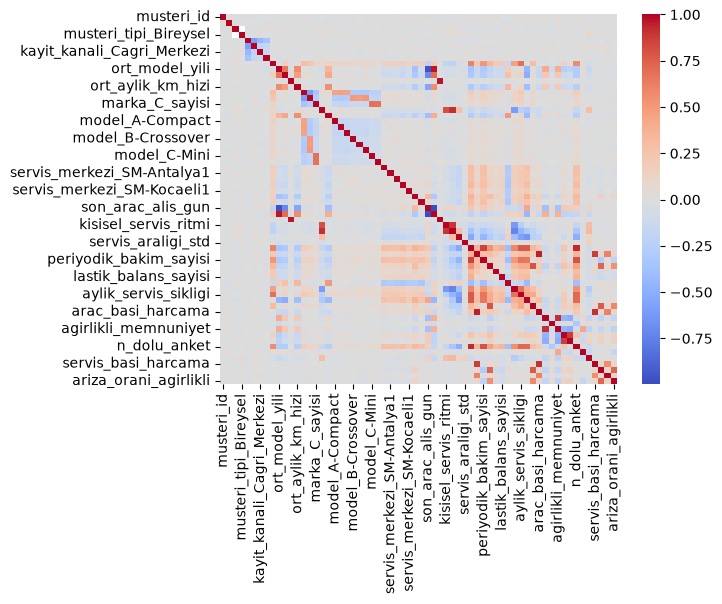

In [13]:
import seaborn as sns
korelasyon = musteri_feature_tablosu.select_dtypes(include='number').corr()
sns.heatmap(korelasyon, annot=False, cmap='coolwarm')

In [14]:
import numpy as np


def yuksek_korelasyon_ciftlerini_bul(veri, esik=0.75):
    korelasyon = veri.select_dtypes(include='number').corr()

    # Üst üçgeni al (aynı çifti iki kere görmemek için), diagonal'i çıkar
    mask = np.triu(np.ones(korelasyon.shape), k=1).astype(bool)
    korelasyon_uctgen = korelasyon.where(mask)

    yuksek_ciftler = (
        korelasyon_uctgen.stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'korelasyon'})
    )
    return yuksek_ciftler[
        yuksek_ciftler['korelasyon'].abs() > esik
    ].sort_values('korelasyon', key=abs, ascending=False)


esik = 0.75
yuksek_ciftler = yuksek_korelasyon_ciftlerini_bul(musteri_feature_tablosu, esik)
print(yuksek_ciftler)

                   feature_1                   feature_2  korelasyon
2146       son_arac_alis_gun  son_alinan_arac_model_yili   -0.996622
739               ort_ilk_km      son_alinan_arac_ilk_km    0.963131
610           ort_model_yili  son_alinan_arac_model_yili    0.962841
609           ort_model_yili           son_arac_alis_gun   -0.960016
2675          toplam_harcama           arac_basi_harcama    0.950178
2617    toplam_servis_sayisi                n_dolu_anket    0.925888
3324       arac_basi_harcama         servis_basi_harcama    0.911988
3382          ort_memnuniyet        agirlikli_memnuniyet    0.910775
1061           gecikme_orani                 recency_gun    0.907882
2341    kisisel_servis_ritmi                 recency_gun    0.893144
3576       dusuk_puan_sayisi            dusuk_puan_orani    0.874377
2684          toplam_harcama         servis_basi_harcama    0.868297
2602    toplam_servis_sayisi      periyodik_bakim_sayisi    0.854237
1060           gecikme_orani      

# Model girdisi seçimi

Analiz tablosu korunurken modele alınmayacak sütunlar ayrılır; kalan özelliklerle X ve churn etiketleriyle y oluşturulur.

In [15]:
from IPython.display import display

# Üç örtüşen feature hesaplama aşamasında kaldırıldı; kalan seçim X'e uygulanır.
musteri_final_tablo = musteri_feature_tablosu.copy()
model_disinda_tutulacak = [
    'ort_model_yili',
    'son_alinan_arac_model_yili',  # son_arac_alis_gun ile neredeyse aynı bilgi.
    'arac_basi_harcama',
    'servis_araligi_std',
    'toplam_servis_sayisi',
    'gecikme_orani',  # Ortak medyan paydalı eski oran; modelde kişisel ritim kullanılır.
    'recency_gun',  # RFM için tutulur; modelde kişisel servis ritmi kullanılır.
    'toplam_harcama',
    'arac_basi_ort_servis',
    'ort_memnuniyet',
    'dusuk_puan_sayisi',  # dusuk_puan_orani × n_dolu_anket ile hesaplanabilir.
    'servis_basi_harcama_agirlikli',
    'ariza_orani_agirlikli',
    # İş birimine anlatımı zor ve güçlü servis davranışı feature'larıyla örtüşenler.
    'ort_servis_araligi_gun',
    'aylik_servis_sikligi',
    'aylik_ariza_sikligi',
    'ort_ilk_km',
    'yetersiz_servis_gecmisi_var_mi',
    'musteri_yasi_yil',
]
assert set(model_disinda_tutulacak).issubset(musteri_final_tablo.columns)

X = musteri_final_tablo.drop(columns=['musteri_id', 'churn', *model_disinda_tutulacak]).copy()
y = musteri_final_tablo['churn'].copy()

assert musteri_final_tablo['musteri_id'].is_unique
assert len(X) == len(y) == len(musteri_final_tablo)
assert 'servis_basi_harcama' in X.columns and 'toplam_harcama' not in X.columns
assert 'toplam_servis_sayisi' in musteri_final_tablo.columns
assert 'toplam_servis_sayisi' not in X.columns
assert 'gecikme_orani' in musteri_final_tablo.columns and 'gecikme_orani' not in X.columns
assert 'kisisel_servis_ritmi' in X.columns
assert 'servis_merkezi_bagliligi' in X.columns
assert 'son_alinan_arac_ilk_km' in X.columns
assert 'son_alinan_arac_model_yili' in musteri_final_tablo.columns and 'son_alinan_arac_model_yili' not in X.columns
assert 'aylik_harcama' not in musteri_final_tablo.columns
assert 'recency_gun' in musteri_final_tablo.columns and 'recency_gun' not in X.columns
assert {'bos_anket_orani', 'agirlikli_memnuniyet', 'dusuk_puan_orani', 'n_dolu_anket', 'musteri_ilk_temas_suresi_ay', 'son_180_gun_servis_sayisi', 'son_anket_onceki_ortalama_farki'}.issubset(X.columns)
assert not {
    'arac_basi_ort_servis', 'ort_memnuniyet', 'dusuk_puan_sayisi', 'musteri_yasi_ay',
    'servis_basi_harcama_agirlikli', 'ariza_orani_agirlikli', 'ort_servis_araligi_gun', 'aylik_servis_sikligi',
    'aylik_ariza_sikligi', 'ort_ilk_km', 'yetersiz_servis_gecmisi_var_mi',
    'musteri_yasi_yil',
}.intersection(X.columns)
assert {'ort_aylik_km_hizi', 'ariza_onarim_sayisi', 'ariza_orani'}.issubset(X.columns)
assert not {'ort_memnuniyet_puani', 'anket_yanit_orani', 'musteri_tipi_Kurumsal'}.intersection(musteri_final_tablo.columns)
assert not {'musteri_id', 'churn'}.intersection(X.columns)
assert not X.columns.duplicated().any()

# Üretime alınacak X sütunlarının açıklamalarını burada tut; yeni feature eklenirse açıklama da zorunlu olsun.
prod_feature_aciklamalari = {
    'kisisel_servis_ritmi': 'Müşterinin en son servis gördüğü araçta, son servisten beri geçen günün o aracın ortalama servis aralığına oranıdır.',
    'son_180_gun_servis_sayisi': 'Kesim tarihinden geriye doğru 180 takvim gününde müşterinin yaptığı servis ziyaretlerinin sayısıdır.',
    'agirlikli_memnuniyet': 'Müşterinin dolu anket puanlarının, son tarihlere daha fazla ağırlık veren 365 günlük yarı ömürlü ortalamasıdır.',
    'son_arac_alis_gun': 'Müşterinin en son satın aldığı araç alışından kesim tarihine kadar geçen gün sayısıdır.',
    'son_anket_onceki_ortalama_farki': 'Son dolu anket puanının, önceki dolu anketlerin ortalamasından farkıdır; tek anket varsa tanımsızdır.',
    'dusuk_puan_orani': 'Müşterinin dolu anketleri içinde 2 veya daha düşük puanların oranıdır.',
    'n_dolu_anket': 'Kesim tarihine kadar müşterinin verdiği dolu memnuniyet anketlerinin sayısıdır.',
    'musteri_tipi_Bireysel': 'Müşterinin bireysel müşteri olduğunu gösteren 0/1 göstergesidir.',
    'aktif_garanti_var_mi': 'Müşterinin en az bir aracının kesim tarihinde garantisinin devam edip etmediğini gösterir.',
    'arac_sayisi': 'Müşteriye ait, kesim tarihinden önce satın alınmış araçların sayısıdır.',
    'ort_aylik_km_hizi': 'Müşterinin araçları için ilk ve son geçerli kilometre ölçümlerinden hesaplanan aylık kilometre hızlarının ortalamasıdır.',
    'lastik_balans_sayisi': 'Müşterinin geçmiş servis kayıtlarındaki lastik/balans işlemlerinin sayısıdır.',
    'periyodik_bakim_sayisi': 'Müşterinin geçmiş servis kayıtlarındaki periyodik bakım işlemlerinin sayısıdır.',
    'ariza_onarim_sayisi': 'Müşterinin geçmiş servis kayıtlarındaki arıza onarım işlemlerinin sayısıdır.',
    'bos_anket_orani': 'Müşterinin servis ziyaretleri içinde memnuniyet puanı girilmemiş ziyaretlerin oranıdır.',
    'servis_merkezi_SM-Bursa1': 'Müşterinin geçmişte SM-Bursa1 merkezinde en az bir servis kaydı olup olmadığını gösterir.',
    'kayit_kanali_Bayi': 'Müşteri kaydının Bayi kanalı üzerinden yapılıp yapılmadığını gösteren 0/1 göstergesidir.',
    'servis_merkezi_SM-Kadıköy': 'Müşterinin geçmişte SM-Kadıköy merkezinde en az bir servis kaydı olup olmadığını gösterir.',
    'kayit_kanali_Web': 'Müşteri kaydının Web kanalı üzerinden yapılıp yapılmadığını gösteren 0/1 göstergesidir.',
    'marka_A_sayisi': 'Müşteriye ait Marka-A araçlarının sayısıdır.',
    'kaporta_boya_sayisi': 'Müşterinin geçmiş servis kayıtlarındaki kaporta/boya işlemlerinin sayısıdır.',
    'servis_merkezi_SM-Maslak': 'Müşterinin geçmişte SM-Maslak merkezinde en az bir servis kaydı olup olmadığını gösterir.',
    'model_A-Compact': 'Müşteriye ait araçlar arasında A-Compact modelinin bulunup bulunmadığını gösterir.',
    'servis_merkezi_SM-İzmir1': 'Müşterinin geçmişte SM-İzmir1 merkezinde en az bir servis kaydı olup olmadığını gösterir.',
    'servis_merkezi_SM-Ankara1': 'Müşterinin geçmişte SM-Ankara1 merkezinde en az bir servis kaydı olup olmadığını gösterir.',
    'model_B-Crossover': 'Müşteriye ait araçlar arasında B-Crossover modelinin bulunup bulunmadığını gösterir.',
    'servis_merkezi_SM-Antalya1': 'Müşterinin geçmişte SM-Antalya1 merkezinde en az bir servis kaydı olup olmadığını gösterir.',
    'son_alinan_arac_ilk_km': 'Müşterinin en son satın aldığı aracın kayıtlardaki ilk kilometre değeridir.',
    'kayit_kanali_Mobil_Uygulama': 'Müşteri kaydının Mobil Uygulama üzerinden yapılıp yapılmadığını gösteren 0/1 göstergesidir.',
    'musteri_ilk_temas_suresi_ay': 'Müşterinin ilk temas tarihinden kesim tarihine kadar geçen sürenin ay cinsinden değeridir.',
    'model_C-Van': 'Müşteriye ait araçlar arasında C-Van modelinin bulunup bulunmadığını gösterir.',
    'marka_C_sayisi': 'Müşteriye ait Marka-C araçlarının sayısıdır.',
    'model_B-Hatch': 'Müşteriye ait araçlar arasında B-Hatch modelinin bulunup bulunmadığını gösterir.',
    'model_B-Touring': 'Müşteriye ait araçlar arasında B-Touring modelinin bulunup bulunmadığını gösterir.',
    'ariza_orani': 'Müşterinin servis ziyaretleri içinde arıza onarımı olan kayıtların oranıdır.',
    'model_A-SUV': 'Müşteriye ait araçlar arasında A-SUV modelinin bulunup bulunmadığını gösterir.',
    'servis_merkezi_SM-Kocaeli1': 'Müşterinin geçmişte SM-Kocaeli1 merkezinde en az bir servis kaydı olup olmadığını gösterir.',
    'kayit_kanali_Cagri_Merkezi': 'Müşteri kaydının Çağrı Merkezi üzerinden yapılıp yapılmadığını gösteren 0/1 göstergesidir.',
    'model_C-Mini': 'Müşteriye ait araçlar arasında C-Mini modelinin bulunup bulunmadığını gösterir.',
    'servis_merkezi_bagliligi': 'Müşterinin en sık kullandığı merkezin ziyaretlerinin tüm servis ziyaretlerine oranıdır.',
    'model_A-Sedan': 'Müşteriye ait araçlar arasında A-Sedan modelinin bulunup bulunmadığını gösterir.',
    'marka_B_sayisi': 'Müşteriye ait Marka-B araçlarının sayısıdır.',
    'servis_basi_harcama': 'Müşterinin toplam servis harcamasının toplam servis ziyareti sayısına bölünmüş değeridir.',
}
assert set(prod_feature_aciklamalari) == set(X.columns), (set(X.columns) - set(prod_feature_aciklamalari), set(prod_feature_aciklamalari) - set(X.columns))
prod_feature_aciklama_tablosu = pd.DataFrame([
    {'feature': ad, 'açıklama': prod_feature_aciklamalari[ad]} for ad in X.columns
])
print('PROD MODEL GİRDİSİ — FEATURE AÇIKLAMALARI')
display(prod_feature_aciklama_tablosu)

print(f'EDA/analiz tablosu: {musteri_final_tablo.shape[0]:,} satır × {musteri_final_tablo.shape[1]} sütun')
print(f'Model girdisi X: {X.shape[0]:,} satır × {X.shape[1]} feature')
print(f'Hedef y: {len(y):,} etiket; churn=0: {int(y.eq(0).sum()):,}, churn=1: {int(y.eq(1).sum()):,}')
print('Yalnızca X dışında tutulan feature’lar:')
display(pd.DataFrame({'model_disinda_tutulacak': model_disinda_tutulacak}))
print('EDA tablosunda korunan, model girdisine alınmayan toplam_servis_sayisi:',
      'toplam_servis_sayisi' in musteri_final_tablo and 'toplam_servis_sayisi' not in X)
print(f'Eski gecikme oranı ile kişisel servis ritmi korelasyonu: {musteri_final_tablo["gecikme_orani"].corr(musteri_final_tablo["kisisel_servis_ritmi"]):.3f}')
print('EDA tablosunda toplam_harcama korunup X dışında bırakıldı:',
      'toplam_harcama' in musteri_final_tablo and 'toplam_harcama' not in X)

esik = 0.75
print("Yüksek korelasyonlu feature çiftleri (eşik > {:.2f}):".format(esik))
yuksek_ciftler = yuksek_korelasyon_ciftlerini_bul(X, esik)
print(yuksek_ciftler)

PROD MODEL GİRDİSİ — FEATURE AÇIKLAMALARI


,feature,açıklama
0,musteri_ilk_temas_suresi_ay,Müşterinin ilk temas tarihinden kesim tarihine...
1,musteri_tipi_Bireysel,Müşterinin bireysel müşteri olduğunu gösteren ...
2,kayit_kanali_Bayi,Müşteri kaydının Bayi kanalı üzerinden yapılıp...
3,kayit_kanali_Web,Müşteri kaydının Web kanalı üzerinden yapılıp ...
4,kayit_kanali_Cagri_Merkezi,Müşteri kaydının Çağrı Merkezi üzerinden yapıl...
5,kayit_kanali_Mobil_Uygulama,Müşteri kaydının Mobil Uygulama üzerinden yapı...
6,arac_sayisi,"Müşteriye ait, kesim tarihinden önce satın alı..."
7,aktif_garanti_var_mi,Müşterinin en az bir aracının kesim tarihinde ...
8,ort_aylik_km_hizi,Müşterinin araçları için ilk ve son geçerli ki...
9,marka_A_sayisi,Müşteriye ait Marka-A araçlarının sayısıdır.


EDA/analiz tablosu: 3,973 satır × 64 sütun
Model girdisi X: 3,973 satır × 43 feature
Hedef y: 3,973 etiket; churn=0: 3,315, churn=1: 658
Yalnızca X dışında tutulan feature’lar:


,model_disinda_tutulacak
0,ort_model_yili
1,son_alinan_arac_model_yili
2,arac_basi_harcama
3,servis_araligi_std
4,toplam_servis_sayisi
5,gecikme_orani
6,recency_gun
7,toplam_harcama
8,arac_basi_ort_servis
9,ort_memnuniyet


EDA tablosunda korunan, model girdisine alınmayan toplam_servis_sayisi: True
Eski gecikme oranı ile kişisel servis ritmi korelasyonu: 0.807
EDA tablosunda toplam_harcama korunup X dışında bırakıldı: True
Yüksek korelasyonlu feature çiftleri (eşik > 0.75):
                   feature_1     feature_2  korelasyon
1329  periyodik_bakim_sayisi  n_dolu_anket    0.803966


## Seçilen model girdisinin korelasyonu

Seçilen X içindeki yüksek korelasyonlu çiftler ve her özelliğin churn ile ilişkisi tablo halinde gösterilir.

In [16]:
from IPython.display import display
import numpy as np

# Yalnızca seçilmiş model girdisi X; müşteri kimliği ve churn matrise girmez.
model_korelasyon = X.corr(numeric_only=True)
ust_ucgen = model_korelasyon.where(
    np.triu(np.ones(model_korelasyon.shape, dtype=bool), k=1)
)
model_yuksek_korelasyon = (
    ust_ucgen.stack().rename('korelasyon').reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
)
model_yuksek_korelasyon = (
    model_yuksek_korelasyon.loc[model_yuksek_korelasyon['korelasyon'].abs().ge(0.85)]
    .sort_values('korelasyon', key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)
model_churn_korelasyonu = X.corrwith(y).dropna().rename('churn_korelasyonu')
model_churn_korelasyonu = (
    model_churn_korelasyonu.reindex(
        model_churn_korelasyonu.abs().sort_values(ascending=False).index
    ).reset_index().rename(columns={'index': 'feature'})
)

print(f'SEÇİLEN MODEL GİRDİSİ — {len(X):,} müşteri, {X.shape[1]} feature')
print(f'|r| ≥ 0,85 olan feature çifti: {len(model_yuksek_korelasyon)}')
display(model_yuksek_korelasyon)
print('CHURN İLE KORELASYON — X İÇİNDEKİ TÜM FEATURE’LAR')
display(model_churn_korelasyonu)
print('Not: Pearson korelasyonu tek değişkenli ilişkiyi gösterir; model katkısı kanıtı değildir.')


SEÇİLEN MODEL GİRDİSİ — 3,973 müşteri, 43 feature
|r| ≥ 0,85 olan feature çifti: 0


,feature_1,feature_2,korelasyon


CHURN İLE KORELASYON — X İÇİNDEKİ TÜM FEATURE’LAR


,feature,churn_korelasyonu
0,kisisel_servis_ritmi,0.298759
1,son_180_gun_servis_sayisi,-0.272440
2,agirlikli_memnuniyet,-0.223070
3,son_arac_alis_gun,0.147531
4,son_anket_onceki_ortalama_farki,-0.143396
5,dusuk_puan_orani,0.131229
6,n_dolu_anket,-0.120353
7,musteri_tipi_Bireysel,0.098584
8,aktif_garanti_var_mi,-0.096865
9,arac_sayisi,-0.083564


Not: Pearson korelasyonu tek değişkenli ilişkiyi gösterir; model katkısı kanıtı değildir.


### Korelasyon grafikleri

Seçilen özelliklerin birbirleriyle ve churn ile korelasyonları grafik üzerinde topluca gösterilir.

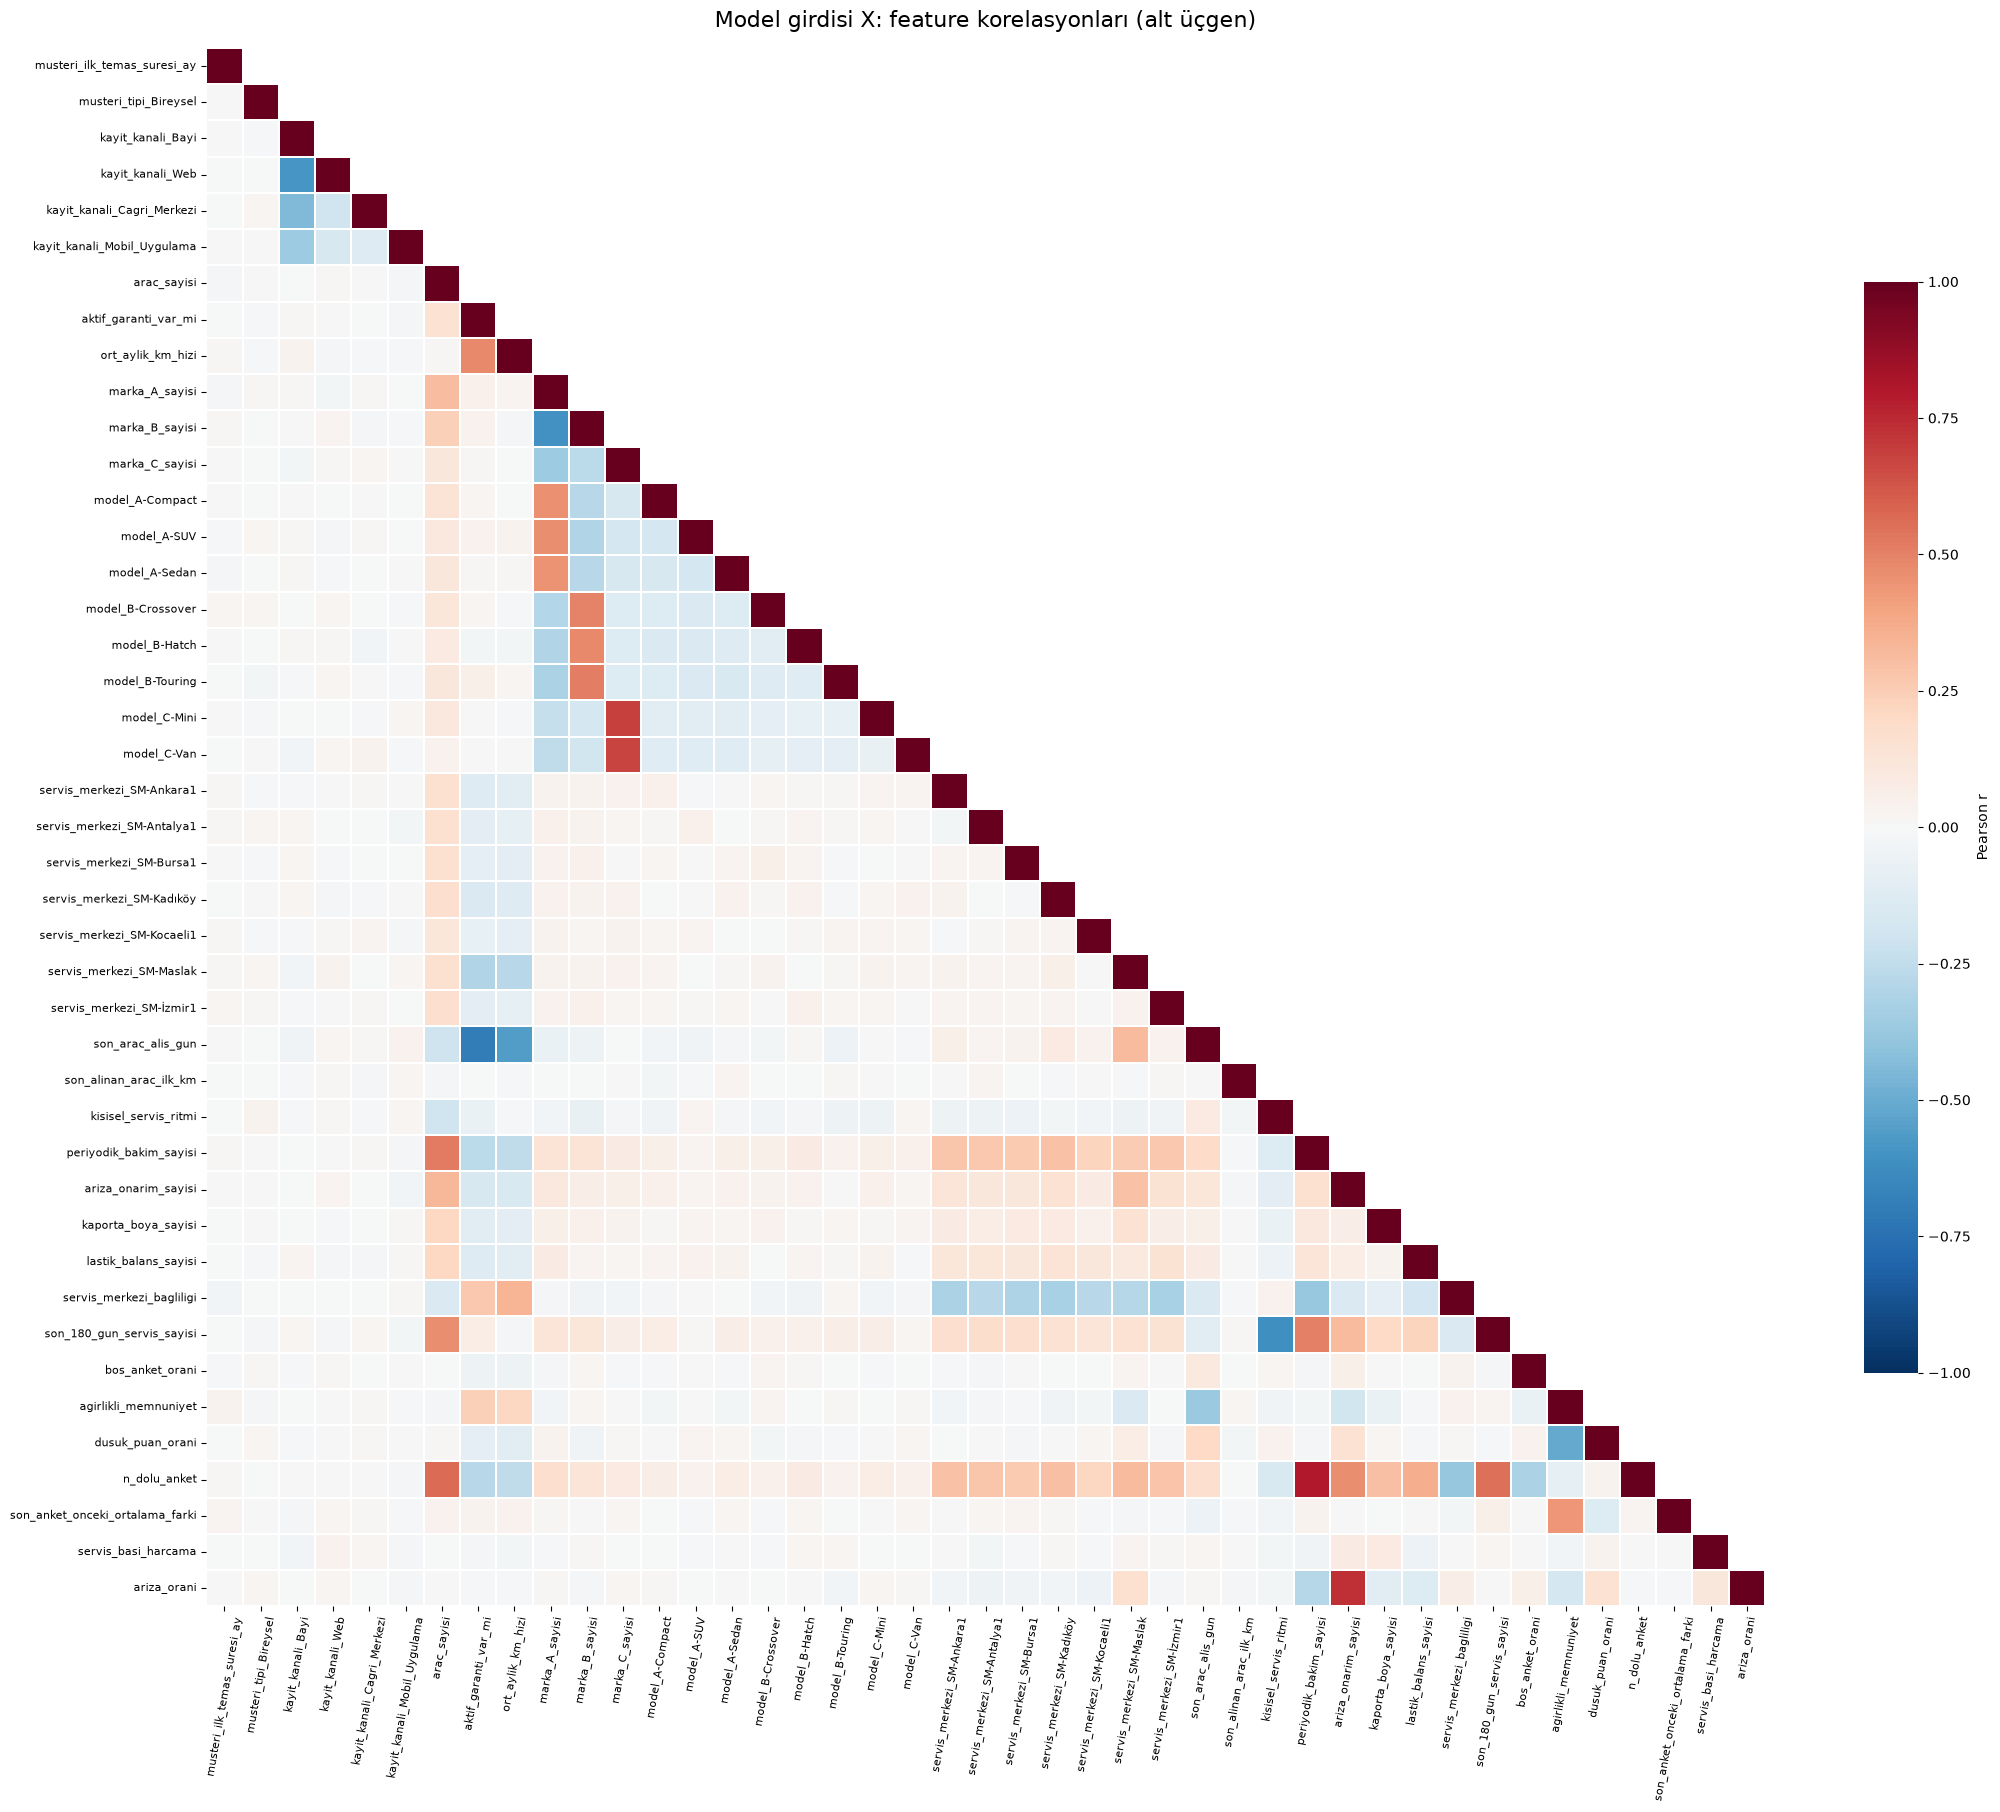

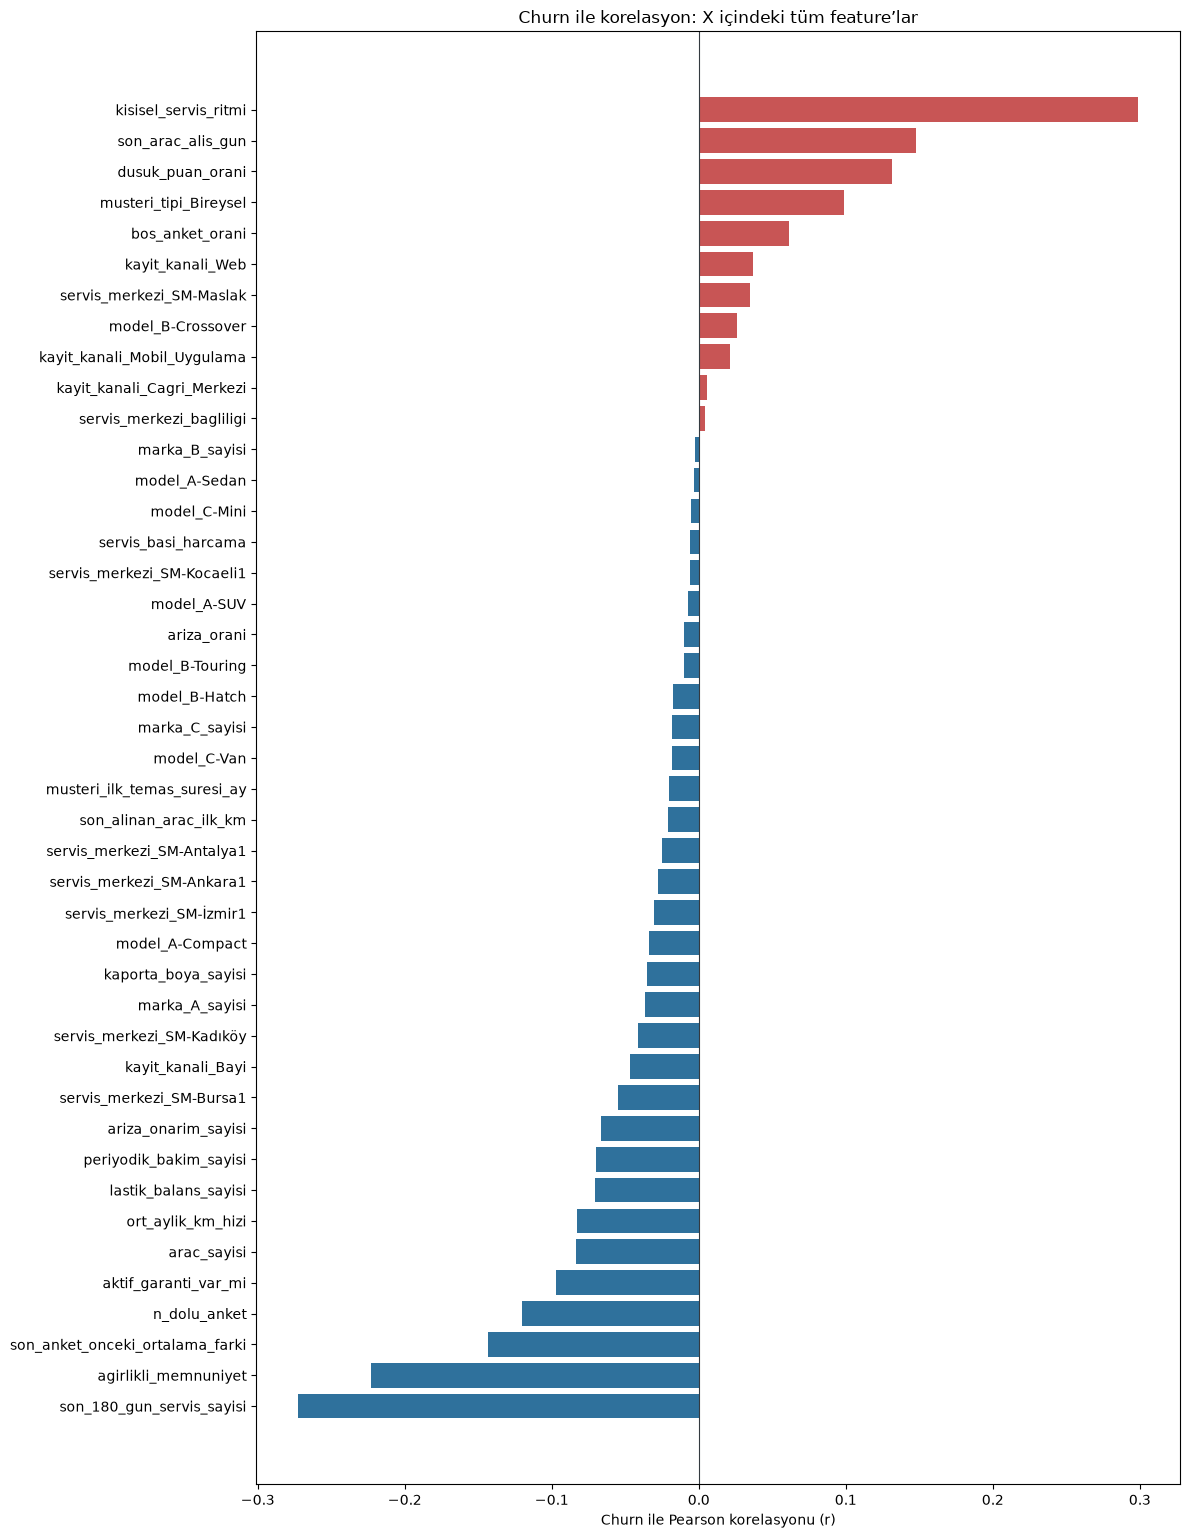

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tam korelasyon haritası, yalnızca X sütunları (musteri_id ve churn hariç).
ust_ucgen_maskesi = np.triu(np.ones(model_korelasyon.shape, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(model_korelasyon, mask=ust_ucgen_maskesi, cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.15,
            cbar_kws={'label': 'Pearson r', 'shrink': .7}, ax=ax)
ax.set_title('Model girdisi X: feature korelasyonları (alt üçgen)', fontsize=16, pad=15)
ax.tick_params(axis='x', labelrotation=80, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
fig.tight_layout()
plt.show()

# Churn ile tek değişkenli Pearson korelasyonu; işaret ve büyüklük birlikte görünür.
grafik_verisi = model_churn_korelasyonu.sort_values('churn_korelasyonu')
renkler = ['#C85555' if deger > 0 else '#2F719C'
           for deger in grafik_verisi['churn_korelasyonu']]
fig, ax = plt.subplots(figsize=(12, max(10, len(grafik_verisi) * 0.36)))
ax.barh(grafik_verisi['feature'], grafik_verisi['churn_korelasyonu'], color=renkler)
ax.axvline(0, color='#343A40', linewidth=.8)
ax.set_xlabel('Churn ile Pearson korelasyonu (r)')
ax.set_title('Churn ile korelasyon: X içindeki tüm feature’lar')
fig.tight_layout()
plt.show()


# Seçim sonrası EDA

Model girdisindeki eksik değerler, churn sınıflarının dağılımı ve seçili özelliklerin sınıf bazındaki özetleri incelenir.

In [18]:
from IPython.display import display

eda_eksik_degerler = X.isna().sum().loc[lambda s: s.gt(0)].sort_values(ascending=False)
eda_sinif_dagilimi = y.value_counts().sort_index().rename_axis('churn').to_frame('musteri_sayisi')
eda_sinif_dagilimi['oran_yuzde'] = (eda_sinif_dagilimi['musteri_sayisi'] / len(y) * 100).round(2)
eda_secili_featurelar = [
    'kisisel_servis_ritmi', 'son_180_gun_servis_sayisi', 'ort_aylik_km_hizi',
    'agirlikli_memnuniyet', 'servis_basi_harcama',
]
eda_churn_medyani = (X[eda_secili_featurelar].assign(churn=y)
                     .groupby('churn')[eda_secili_featurelar].median().T)

print(f'MODEL EDA — {len(X):,} müşteri, {X.shape[1]} feature')
print(f'Eksik değerli feature: {len(eda_eksik_degerler)}; '
      f'toplam eksik hücre: {int(eda_eksik_degerler.sum())}')
print('SINIF DAĞILIMI')
display(eda_sinif_dagilimi)
print('EKSİK DEĞERLER')
display(eda_eksik_degerler.to_frame('eksik_sayisi'))
print('SEÇİLİ FEATURE MEDYANLARI — CHURN SINIFINA GÖRE')
display(eda_churn_medyani)


MODEL EDA — 3,973 müşteri, 43 feature
Eksik değerli feature: 3; toplam eksik hücre: 361
SINIF DAĞILIMI


,musteri_sayisi,oran_yuzde
churn,,
0,3315,83.44
1,658,16.56


EKSİK DEĞERLER


,eksik_sayisi
son_anket_onceki_ortalama_farki,269
agirlikli_memnuniyet,46
dusuk_puan_orani,46


SEÇİLİ FEATURE MEDYANLARI — CHURN SINIFINA GÖRE


churn,0,1
kisisel_servis_ritmi,0.465753,0.798743
son_180_gun_servis_sayisi,1.000000,1.000000
ort_aylik_km_hizi,26.754373,19.918051
agirlikli_memnuniyet,4.000000,3.667145
servis_basi_harcama,11545.481111,11283.640500


# Vaka 1.3 — Keşifsel analiz: churn gruplarında üç ayrı bulgu

Terk eden ve etmeyen müşteriler servis ritmi, yakın dönem servis etkinliği ve memnuniyet açısından üç ayrı tablo ve grafikle karşılaştırılır.

## Bulgu 1 — Terk edenler kendi servis ritimlerinden daha uzun süre uzak kalmış

Kişisel servis ritmi churn gruplarında karşılaştırılır; tablo ve grafik müşterilerin alışılmış ziyaret düzeninden ne kadar uzaklaştığını gösterir.

BULGU 1 — KİŞİSEL SERVİS RİTMİ, CHURN GRUPLARI


,musteri_sayisi,olculen_musteri,medyan_ritim,ortalama_ritim
churn,,,,
Terk etmeyen (0),3315,3315,0.466,0.503
Terk eden (1),658,658,0.799,0.814


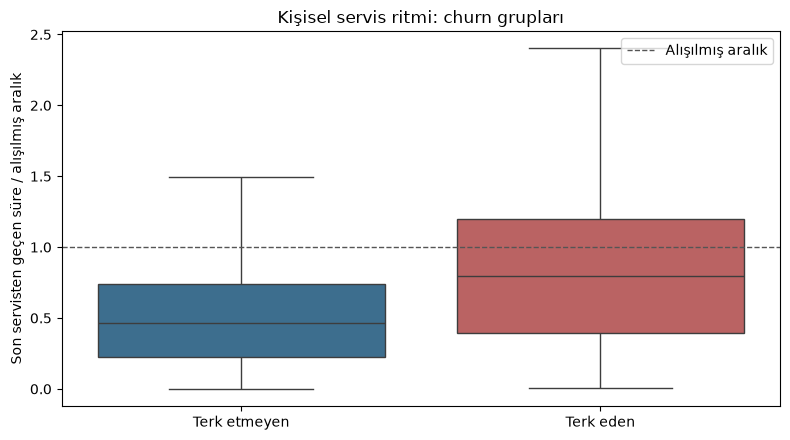

Kutu grafiğinde uç değerler yalnızca görünüm için gizlidir.


In [19]:
from IPython.display import display

bulgu_1 = musteri_final_tablo.groupby('churn').agg(
    musteri_sayisi=('musteri_id', 'size'),
    olculen_musteri=('kisisel_servis_ritmi', 'count'),
    medyan_ritim=('kisisel_servis_ritmi', 'median'),
    ortalama_ritim=('kisisel_servis_ritmi', 'mean'),
).rename(index={0: 'Terk etmeyen (0)', 1: 'Terk eden (1)'})
print('BULGU 1 — KİŞİSEL SERVİS RİTMİ, CHURN GRUPLARI')
display(bulgu_1.round(3))

# Dağılımı ve medyan farkını aynı eksende göster.
import matplotlib.pyplot as plt
import seaborn as sns

ritim_grafik = musteri_final_tablo[['churn', 'kisisel_servis_ritmi']].copy()
ritim_grafik['grup'] = ritim_grafik['churn'].map({0: 'Terk etmeyen', 1: 'Terk eden'})
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=ritim_grafik, x='grup', y='kisisel_servis_ritmi',
            order=['Terk etmeyen', 'Terk eden'],
            hue='grup', palette={'Terk etmeyen': '#2F719C', 'Terk eden': '#C85555'},
            legend=False, showfliers=False, ax=ax)
ax.set(title='Kişisel servis ritmi: churn grupları', xlabel='',
       ylabel='Son servisten geçen süre / alışılmış aralık')
ax.axhline(1, color='#555555', linestyle='--', linewidth=1, label='Alışılmış aralık')
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()
print('Kutu grafiğinde uç değerler yalnızca görünüm için gizlidir.')


## Bulgu 2 — Terk edenlerin son 180 gündeki servis etkinliği daha düşük

Son 180 gündeki servis sayısı ve bu dönemde servise gelen müşteri payı churn grupları arasında karşılaştırılır.

BULGU 2 — SON 180 GÜN SERVİS ETKİNLİĞİ, CHURN GRUPLARI


,musteri_sayisi,medyan_son_180_gun_servis,ortalama_son_180_gun_servis,son_180_gunde_servisi_olan_yuzde
churn,,,,
Terk etmeyen (0),3315,1.0,1.05,83.41
Terk eden (1),658,1.0,0.55,52.13


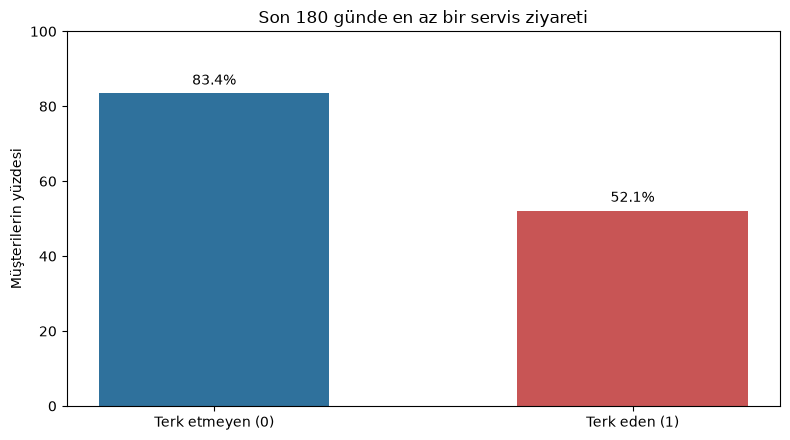

In [20]:
bulgu_2 = musteri_final_tablo.groupby('churn').agg(
    musteri_sayisi=('musteri_id', 'size'),
    medyan_son_180_gun_servis=('son_180_gun_servis_sayisi', 'median'),
    ortalama_son_180_gun_servis=('son_180_gun_servis_sayisi', 'mean'),
    son_180_gunde_servisi_olan_orani=('son_180_gun_servis_sayisi', lambda s: s.gt(0).mean()),
).rename(index={0: 'Terk etmeyen (0)', 1: 'Terk eden (1)'})
bulgu_2['son_180_gunde_servisi_olan_yuzde'] = 100 * bulgu_2.pop('son_180_gunde_servisi_olan_orani')
print('BULGU 2 — SON 180 GÜN SERVİS ETKİNLİĞİ, CHURN GRUPLARI')
display(bulgu_2.round(2))

# Medyanlar eşit olduğu için gruplar arası farkı ziyaret eden müşteri payıyla göster.
oranlar = bulgu_2['son_180_gunde_servisi_olan_yuzde']
fig, ax = plt.subplots(figsize=(8, 4.5))
renkler = ['#2F719C', '#C85555']
cubuklar = ax.bar(oranlar.index, oranlar.values, color=renkler, width=0.55)
ax.bar_label(cubuklar, fmt='%.1f%%', padding=4)
ax.set(title='Son 180 günde en az bir servis ziyareti', xlabel='',
       ylabel='Müşterilerin yüzdesi', ylim=(0, 100))
fig.tight_layout()
plt.show()


## Bulgu 3 — Terk edenlerin güncel memnuniyet puanı daha düşük

Yakın tarihli anketlere daha çok ağırlık veren memnuniyet puanları churn gruplarında karşılaştırılır; anket kapsamı da gösterilir.

BULGU 3 — GÜNCEL MEMNUNİYET, CHURN GRUPLARI


,musteri_sayisi,anket_verisi_olan_musteri,medyan_agirlikli_memnuniyet,ortalama_agirlikli_memnuniyet,anket_kapsama_yuzde
churn,,,,,
Terk etmeyen (0),3315,3275,4.00,3.97,98.79
Terk eden (1),658,652,3.67,3.66,99.09


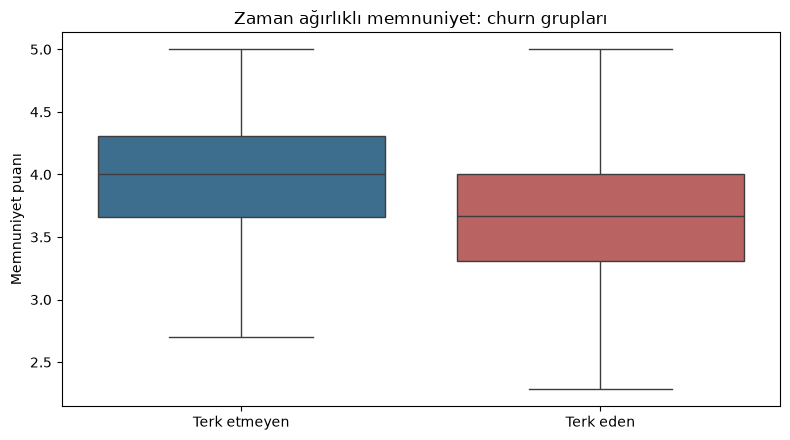

Kutu grafiğinde uç değerler yalnızca görünüm için gizlidir; anketi olmayanlar tabloda raporlanır.


In [21]:
bulgu_3 = musteri_final_tablo.groupby('churn').agg(
    musteri_sayisi=('musteri_id', 'size'),
    anket_verisi_olan_musteri=('agirlikli_memnuniyet', 'count'),
    medyan_agirlikli_memnuniyet=('agirlikli_memnuniyet', 'median'),
    ortalama_agirlikli_memnuniyet=('agirlikli_memnuniyet', 'mean'),
).rename(index={0: 'Terk etmeyen (0)', 1: 'Terk eden (1)'})
bulgu_3['anket_kapsama_yuzde'] = 100 * bulgu_3['anket_verisi_olan_musteri'] / bulgu_3['musteri_sayisi']
print('BULGU 3 — GÜNCEL MEMNUNİYET, CHURN GRUPLARI')
display(bulgu_3.round(2))

# Yalnızca dolu anketlerden türetilmiş müşteri skorlarını karşılaştır.
memnuniyet_grafik = musteri_final_tablo[['churn', 'agirlikli_memnuniyet']].dropna().copy()
memnuniyet_grafik['grup'] = memnuniyet_grafik['churn'].map({0: 'Terk etmeyen', 1: 'Terk eden'})
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=memnuniyet_grafik, x='grup', y='agirlikli_memnuniyet',
            order=['Terk etmeyen', 'Terk eden'],
            hue='grup', palette={'Terk etmeyen': '#2F719C', 'Terk eden': '#C85555'},
            legend=False, showfliers=False, ax=ax)
ax.set(title='Zaman ağırlıklı memnuniyet: churn grupları', xlabel='',
       ylabel='Memnuniyet puanı')
fig.tight_layout()
plt.show()
print('Kutu grafiğinde uç değerler yalnızca görünüm için gizlidir; anketi olmayanlar tabloda raporlanır.')


# Vaka 1.4 — Servis merkezi memnuniyeti

Servis merkezlerinin ham anket puanları, yanıt oranları ve servis türü farkı giderilmiş puanları karşılaştırılır. Müşteri bazlı sonuç ve hesaplamanın sınırları da gösterilir.

VAKA 1.4 — SERVİS MERKEZİ MEMNUNİYET KARŞILAŞTIRMASI

Amaç: Merkezlerin ham memnuniyet ortalaması, hangi servis türünden (Periyodik Bakım / Arıza Onarım / vb.) daha çok iş aldıklarına göre yanıltıcı olabilir. Aşağıdaki "düzeltilmiş ortalama", her merkezi ağ genelindeki aynı servis türü karışımına sahipmiş GİBİ yeniden hesaplar; böylece merkezler adil şartlarda karşılaştırılır.

SIRALAMA: 1 = EN DÜŞÜK MEMNUNİYET (en kötü), büyük sayı = en iyi



,ziyaret,yanit,yanit_orani_yuzde,ham_ortalama,ham_sira_kotuden_iyiye,tur_duzeltilmis_ortalama,duzeltilmis_sira_kotuden_iyiye,sira_degisimi,duzeltmede_kullanilan_tur_sayisi
servis_merkezi,,,,,,,,,
SM-Maslak,7823,6165,78.806,3.920,1,4.003,7,-6,4
SM-İzmir1,2930,2310,78.840,3.925,2,3.883,1,1,4
SM-Bursa1,2454,1940,79.055,3.939,3,3.899,2,1,4
SM-Kocaeli1,2034,1608,79.056,3.960,4,3.912,3,1,4
SM-Kadıköy,4225,3328,78.769,3.976,5,3.938,5,0,4
SM-Antalya1,2277,1829,80.325,3.979,6,3.935,4,2,4
SM-Ankara1,3292,2612,79.344,3.988,7,3.951,6,1,4



6 merkezin sırası düzeltmeyle DEĞİŞTİ — bu merkezlerde ham ortalama tek başına yanıltıcı olabilir:
  - SM-Maslak: ham sıra=1 → düzeltilmiş sıra=7 (düzeltmeyle daha kötü görünüyor)
  - SM-İzmir1: ham sıra=2 → düzeltilmiş sıra=1 (düzeltmeyle daha iyi görünüyor)
  - SM-Bursa1: ham sıra=3 → düzeltilmiş sıra=2 (düzeltmeyle daha iyi görünüyor)
  - SM-Kocaeli1: ham sıra=4 → düzeltilmiş sıra=3 (düzeltmeyle daha iyi görünüyor)
  - SM-Antalya1: ham sıra=6 → düzeltilmiş sıra=4 (düzeltmeyle daha iyi görünüyor)
  - SM-Ankara1: ham sıra=7 → düzeltilmiş sıra=6 (düzeltmeyle daha iyi görünüyor)

------------------------------------------------------------------------------
SERVİS TÜRÜ KIRILIMI (örnek merkez: en düşük ham ortalamaya sahip merkez)
------------------------------------------------------------------------------
Gösterilen merkez: SM-Maslak



,anket_sayisi,tur_ortalama,merkez_ici_pay_yuzde,ag_geneli_pay_yuzde
servis_tipi,,,,
Arıza Onarım,1996,3.556,32.376,19.336
Kaporta/Boya,635,3.888,10.300,6.892
Lastik/Balans,471,4.104,7.640,10.080
Periyodik Bakım,3063,4.136,49.684,63.692



DÜZELTMEDE KULLANILAN AĞ GENELİ AĞIRLIKLAR (%)


,pay_yuzde
servis_tipi,
Arıza Onarım,19.3
Kaporta/Boya,6.9
Lastik/Balans,10.1
Periyodik Bakım,63.7



------------------------------------------------------------------------------
ÖNEMLİ SINIRLAMALAR
------------------------------------------------------------------------------
1) Bu düzeltme yalnızca "hangi servis türünden ne kadar geldi" (karışım) etkisini ayıklar. Anketi CEVAPLAYAN müşterilerin, cevaplamayanlardan sistematik olarak farklı olma ihtimalini (yanıt yanlılığı) düzeltmez — bir merkezde memnun olmayanlar anketi hiç doldurmuyorsa, düzeltilmiş ortalama da bunu yansıtmaz.
2) "musteri_esit_agirlikli_ortalama" sütunu, aynı müşterinin tekrar ziyaretlerinin ham ortalamayı ne kadar etkilediğini gösterir; bu sütun ile ham ortalama arasında büyük fark varsa, birkaç sadık/aktif müşterinin puanı merkezin genel görünümünü domine ediyor olabilir.


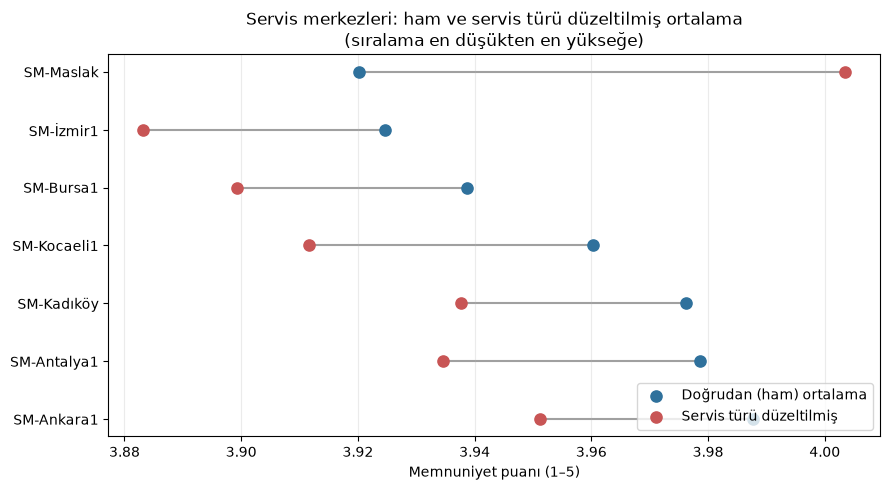

In [22]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Aynı müşteri/servis dönemini kullan: yalnızca kesim tarihine kadarki temiz servisler.
merkez_kayitlari = servis_feature[
    ['kayit_id', 'musteri_id', 'servis_tarihi', 'servis_merkezi', 'servis_tipi', 'memnuniyet_puani']
].copy()
assert merkez_kayitlari['kayit_id'].is_unique
assert merkez_kayitlari['servis_tarihi'].le(kesim_tarihi).all()
assert merkez_kayitlari[['servis_merkezi', 'servis_tipi']].notna().all().all()
puanli = merkez_kayitlari.dropna(subset=['memnuniyet_puani']).copy()

# Ham anket ortalaması ve yanıt kapsamı: payda tüm ziyaret, pay yalnızca puanı dolu anket.
merkez_ozet = merkez_kayitlari.groupby('servis_merkezi').agg(
    ziyaret=('kayit_id', 'size'),
    yanit=('memnuniyet_puani', 'count'),
    tekil_musteri=('musteri_id', 'nunique'),
    ham_ortalama=('memnuniyet_puani', 'mean'),
)
merkez_ozet['yanit_orani_yuzde'] = 100 * merkez_ozet['yanit'] / merkez_ozet['ziyaret']
# rank yönü açıkça etiketleniyor: 1 = en düşük memnuniyet (en kötü), büyük sayı = en iyi.
merkez_ozet['ham_sira_kotuden_iyiye'] = merkez_ozet['ham_ortalama'].rank(method='min').astype(int)

# --- DÜZELTME: eksik merkez × servis türü kombinasyonuna dayanıklı hale getirildi ---
# Ağ geneli servis türü payı (yalnızca puanı dolu anketlerden).
ag_geneli_tur_payi = puanli['servis_tipi'].value_counts(normalize=True).sort_index()
merkez_tur_ortalamasi = (
    puanli.groupby(['servis_merkezi', 'servis_tipi'])['memnuniyet_puani']
    .mean().unstack().reindex(columns=ag_geneli_tur_payi.index)
)

# Eski kod burada sert bir assert ile duruyordu; artık eksik kombinasyonu
# raporlayıp o merkez için mevcut türlerin ağırlığını yeniden normalize ediyoruz.
eksik_kombinasyon = merkez_tur_ortalamasi.isna()
eksik_liste = [
    (merkez, tur)
    for merkez in eksik_kombinasyon.index
    for tur in eksik_kombinasyon.columns
    if eksik_kombinasyon.loc[merkez, tur]
]
if eksik_liste:
    print(f'UYARI: {len(eksik_liste)} merkez × servis türü kombinasyonunda hiç dolu anket yok, '
          'bu kombinasyonlar o merkezin düzeltmesinden çıkarıldı (ağırlıklar kalanlara yeniden dağıtıldı):')
    for merkez, tur in eksik_liste:
        print(f'  - {merkez}: "{tur}" türünde dolu anket yok')

# Mevcut olan (dolu) hücrelerin ağırlığını satır bazında yeniden normalize et.
gecerli_agirlik = merkez_tur_ortalamasi.notna().mul(ag_geneli_tur_payi, axis=1)
gecerli_agirlik = gecerli_agirlik.div(gecerli_agirlik.sum(axis=1), axis=0)
merkez_ozet['tur_duzeltilmis_ortalama'] = (
    merkez_tur_ortalamasi.fillna(0).mul(gecerli_agirlik).sum(axis=1)
)
merkez_ozet['duzeltmede_kullanilan_tur_sayisi'] = merkez_tur_ortalamasi.notna().sum(axis=1)
merkez_ozet['duzeltilmis_sira_kotuden_iyiye'] = (
    merkez_ozet['tur_duzeltilmis_ortalama'].rank(method='min').astype(int)
)

# Ham ve düzeltilmiş sıralama arasında yer değiştiren merkezleri ayrıca vurgula —
# "en kötü merkez" iddiasının düzeltmeden etkilenip etkilenmediğini gösterir.
merkez_ozet['sira_degisimi'] = (
    merkez_ozet['ham_sira_kotuden_iyiye'] - merkez_ozet['duzeltilmis_sira_kotuden_iyiye']
)

# Aynı müşterinin birden çok ziyareti ham ortalamada daha çok ağırlık taşır.
# Kontrol amacıyla her müşteri-merkez çiftinin ortalamasını da bir kez say.
musteri_merkez_puani = puanli.groupby(['servis_merkezi', 'musteri_id'])['memnuniyet_puani'].mean()
merkez_ozet['musteri_esit_agirlikli_ortalama'] = musteri_merkez_puani.groupby('servis_merkezi').mean()
merkez_ozet = merkez_ozet.sort_values('ham_ortalama')

# Ara tablo: servis türü payı ve puanı merkez bazında açıkça gösterilir.
tur_kirilimi = puanli.groupby(['servis_merkezi', 'servis_tipi']).agg(
    anket_sayisi=('memnuniyet_puani', 'size'),
    tur_ortalama=('memnuniyet_puani', 'mean'),
)
tur_kirilimi['merkez_ici_pay_yuzde'] = 100 * tur_kirilimi['anket_sayisi'] / tur_kirilimi.groupby(level=0)['anket_sayisi'].transform('sum')
tur_kirilimi['ag_geneli_pay_yuzde'] = 100 * tur_kirilimi.index.get_level_values('servis_tipi').map(ag_geneli_tur_payi)

cikti_klasoru = Path('../ciktilar')
cikti_klasoru.mkdir(parents=True, exist_ok=True)
merkez_ozet.to_csv(cikti_klasoru / 'vaka_1_4_merkez_ozet.csv', encoding='utf-8-sig')
tur_kirilimi.to_csv(cikti_klasoru / 'vaka_1_4_servis_turu_kirilimi.csv', encoding='utf-8-sig')

# ============================== OKUNAKLI ÖZET ÇIKTI ==============================
print('=' * 78)
print('VAKA 1.4 — SERVİS MERKEZİ MEMNUNİYET KARŞILAŞTIRMASI')
print('=' * 78)
print(
    '\nAmaç: Merkezlerin ham memnuniyet ortalaması, hangi servis türünden '
    '(Periyodik Bakım / Arıza Onarım / vb.) daha çok iş aldıklarına göre yanıltıcı '
    'olabilir. Aşağıdaki "düzeltilmiş ortalama", her merkezi ağ genelindeki aynı '
    'servis türü karışımına sahipmiş GİBİ yeniden hesaplar; böylece merkezler '
    'adil şartlarda karşılaştırılır.\n'
)

goruntu_kolonlari = [
    'ziyaret', 'yanit', 'yanit_orani_yuzde',
    'ham_ortalama', 'ham_sira_kotuden_iyiye',
    'tur_duzeltilmis_ortalama', 'duzeltilmis_sira_kotuden_iyiye',
    'sira_degisimi', 'duzeltmede_kullanilan_tur_sayisi',
]
print('SIRALAMA: 1 = EN DÜŞÜK MEMNUNİYET (en kötü), büyük sayı = en iyi\n')
display(merkez_ozet[goruntu_kolonlari].round(3))

# Sıralaması ham/düzeltilmiş arasında değişen merkezleri ayrıca göster.
sira_degisenler = merkez_ozet.loc[merkez_ozet['sira_degisimi'].ne(0)]
if sira_degisenler.empty:
    print('\nHiçbir merkezin sırası düzeltmeyle değişmedi — servis türü karışımı '
          'sıralamayı etkilemiyor, ham ortalama da güvenle kullanılabilir.')
else:
    print(f'\n{len(sira_degisenler)} merkezin sırası düzeltmeyle DEĞİŞTİ — bu merkezlerde '
          'ham ortalama tek başına yanıltıcı olabilir:')
    for merkez, satir in sira_degisenler.iterrows():
        yon = 'daha kötü' if satir['sira_degisimi'] < 0 else 'daha iyi'
        print(f'  - {merkez}: ham sıra={int(satir["ham_sira_kotuden_iyiye"])} → '
              f'düzeltilmiş sıra={int(satir["duzeltilmis_sira_kotuden_iyiye"])} '
              f'(düzeltmeyle {yon} görünüyor)')

print('\n' + '-' * 78)
print('SERVİS TÜRÜ KIRILIMI (örnek merkez: en düşük ham ortalamaya sahip merkez)')
print('-' * 78)
en_dusuk_merkez = merkez_ozet.index[0]
print(f'Gösterilen merkez: {en_dusuk_merkez}\n')
display(tur_kirilimi.loc[en_dusuk_merkez].round(3))

print('\nDÜZELTMEDE KULLANILAN AĞ GENELİ AĞIRLIKLAR (%)')
display((100 * ag_geneli_tur_payi).round(1).to_frame('pay_yuzde'))

print('\n' + '-' * 78)
print('ÖNEMLİ SINIRLAMALAR')
print('-' * 78)
print(
    '1) Bu düzeltme yalnızca "hangi servis türünden ne kadar geldi" (karışım) '
    'etkisini ayıklar. Anketi CEVAPLAYAN müşterilerin, cevaplamayanlardan '
    'sistematik olarak farklı olma ihtimalini (yanıt yanlılığı) düzeltmez — '
    'bir merkezde memnun olmayanlar anketi hiç doldurmuyorsa, düzeltilmiş '
    'ortalama da bunu yansıtmaz.\n'
    '2) "musteri_esit_agirlikli_ortalama" sütunu, aynı müşterinin tekrar '
    'ziyaretlerinin ham ortalamayı ne kadar etkilediğini gösterir; bu sütun '
    'ile ham ortalama arasında büyük fark varsa, birkaç sadık/aktif müşterinin '
    'puanı merkezin genel görünümünü domine ediyor olabilir.'
)

# ============================== GRAFİK ==============================
fig, ax = plt.subplots(figsize=(9, 5))
grafik = merkez_ozet.sort_values('ham_ortalama', ascending=False)
yerler = range(len(grafik))
for i, satir in enumerate(grafik.itertuples()):
    ax.plot([satir.ham_ortalama, satir.tur_duzeltilmis_ortalama], [i, i],
            color='#A0A0A0', linewidth=1.5, zorder=1)
ax.scatter(grafik['ham_ortalama'], list(yerler), label='Doğrudan (ham) ortalama',
           color='#2F719C', s=65, zorder=2)
ax.scatter(grafik['tur_duzeltilmis_ortalama'], list(yerler), label='Servis türü düzeltilmiş',
           color='#C85555', s=65, zorder=2)
ax.set_yticks(list(yerler), labels=grafik.index)
ax.set_xlabel('Memnuniyet puanı (1–5)')
ax.set_title('Servis merkezleri: ham ve servis türü düzeltilmiş ortalama\n(sıralama en düşükten en yükseğe)')
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(cikti_klasoru / 'vaka_1_4_merkez_karsilastirma.png', dpi=160)
plt.show()

## Churn sınıflarına göre dağılımlar

Churn sınıflarının büyüklüğü ve seçili sayısal özelliklerin sınıflara göre dağılımı grafiklerle incelenir.

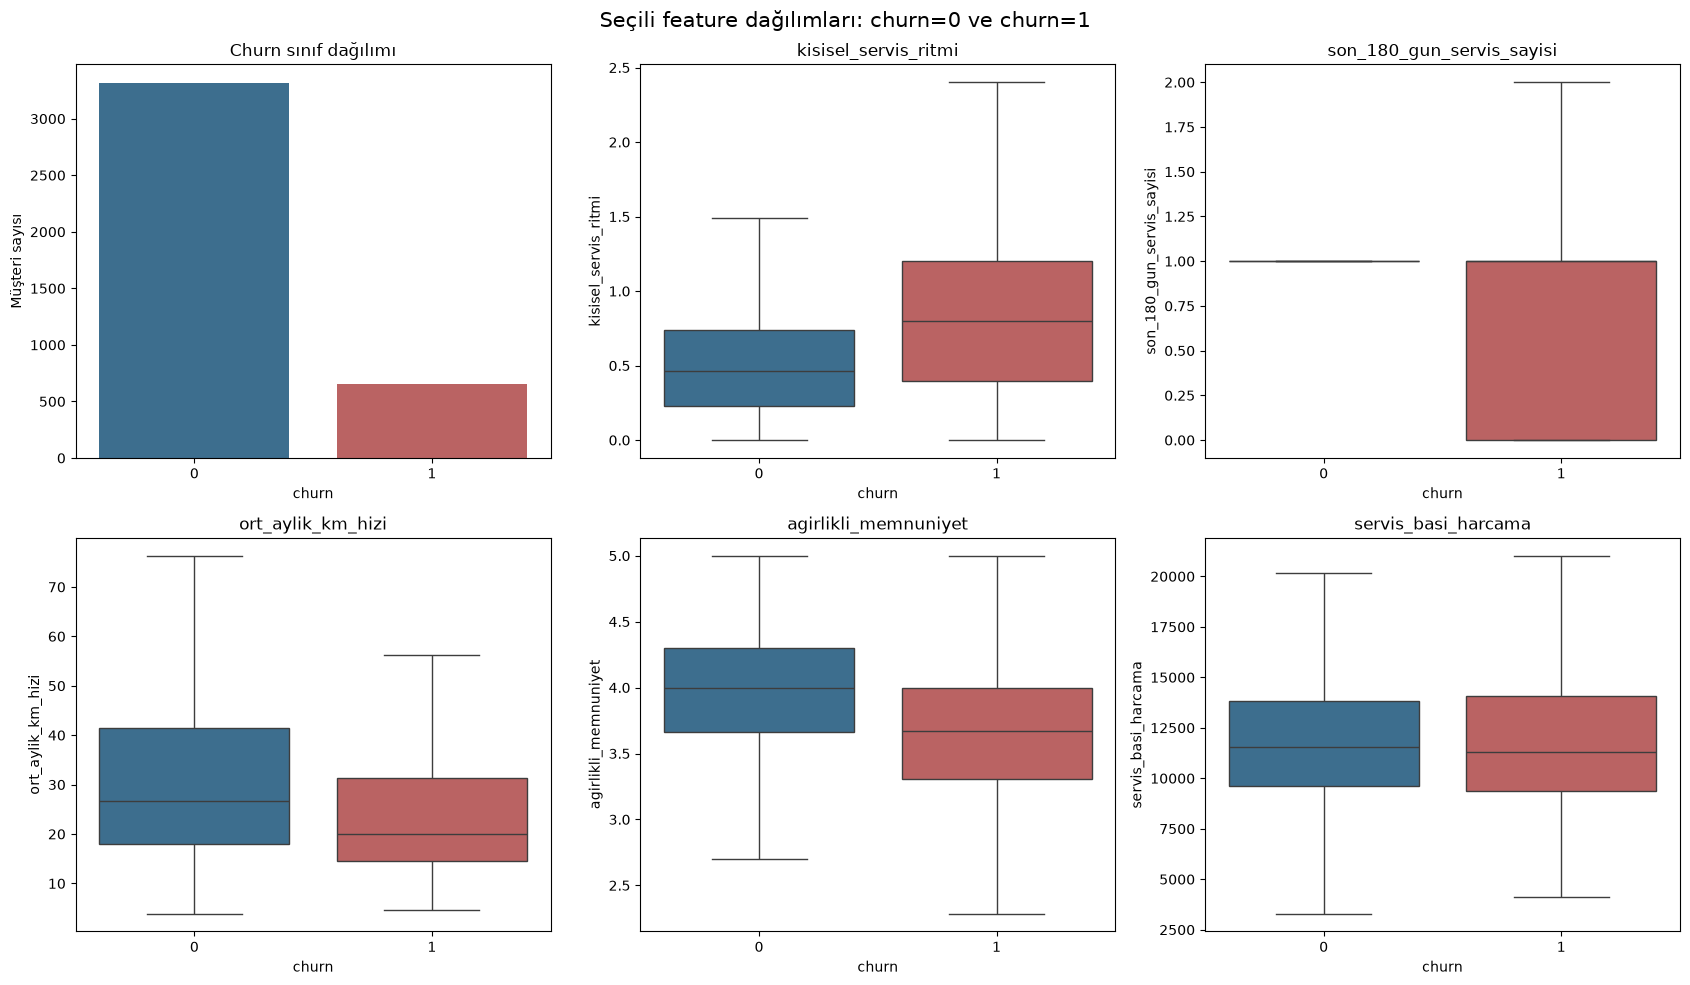

Kutu grafiklerinde uç değerler yalnızca görünüm için gizlidir; veriden çıkarılmadı.


In [23]:
# Sınıf dengesi ve seçili sürekli feature dağılımları; değerler değiştirilmez.
eda_grafik_verisi = X[eda_secili_featurelar].assign(churn=y)
fig, eksenler = plt.subplots(2, 3, figsize=(17, 10))
sns.countplot(data=eda_grafik_verisi, x='churn', hue='churn',
              palette=['#2F719C', '#C85555'], legend=False, ax=eksenler[0, 0])
eksenler[0, 0].set_title('Churn sınıf dağılımı')
eksenler[0, 0].set_ylabel('Müşteri sayısı')
for eksen, kolon in zip(eksenler.flat[1:], eda_secili_featurelar):
    sns.boxplot(data=eda_grafik_verisi, x='churn', y=kolon, hue='churn',
                palette=['#2F719C', '#C85555'], legend=False,
                showfliers=False, ax=eksen)
    eksen.set_title(kolon)
    eksen.set_xlabel('churn')
fig.suptitle('Seçili feature dağılımları: churn=0 ve churn=1', fontsize=15)
fig.tight_layout()
plt.show()
print('Kutu grafiklerinde uç değerler yalnızca görünüm için gizlidir; veriden çıkarılmadı.')


# RandomForest modeli

Seçilmiş müşteri özellikleriyle RandomForest modeli kurulur, çapraz doğrulamayla değerlendirilir ve önemli özellikleri incelenir.

### Model girdisi ve pipeline

X ve y hazırlanır; eksik değerleri dolduran adım ile RandomForest aynı pipeline içine konur. Doldurma değerleri değerlendirme sırasında yalnızca eğitim katından öğrenilir.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Analiz tablosundaki daha önce elenen feature'lar modele yeniden girmesin.
X = musteri_final_tablo.drop(
    columns=['musteri_id', 'churn', *model_disinda_tutulacak]
).copy()
y = musteri_final_tablo['churn'].copy()

beklenen_eksik_kolonlar = {'agirlikli_memnuniyet', 'dusuk_puan_orani', 'son_anket_onceki_ortalama_farki'}
gercek_eksik_kolonlar = set(X.columns[X.isna().any()])
assert gercek_eksik_kolonlar == beklenen_eksik_kolonlar, gercek_eksik_kolonlar
assert X.select_dtypes(include='number').shape[1] == X.shape[1]
assert {'n_dolu_anket', 'bos_anket_orani'}.issubset(X.columns)
assert len(X) == len(y) == len(musteri_final_tablo)

imputer = SimpleImputer(strategy='median')
pipeline = Pipeline([
    ('imputer', imputer),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
    )),
])
print(f'Model girdisi: {X.shape[0]:,} müşteri × {X.shape[1]} feature')
print('Eksik değerli feature’lar:', sorted(gercek_eksik_kolonlar))
print('Eksik değerler: yalnızca eğitim katının medyanıyla doldurulur')
print('Pipeline:', ' → '.join(pipeline.named_steps))


Model girdisi: 3,973 müşteri × 43 feature
Eksik değerli feature’lar: ['agirlikli_memnuniyet', 'dusuk_puan_orani', 'son_anket_onceki_ortalama_farki']
Eksik değerler: yalnızca eğitim katının medyanıyla doldurulur
Pipeline: imputer → model


### Beş katlı çapraz doğrulama ve baseline

Model, churn oranını koruyan beş katlı çapraz doğrulamayla ölçülür ve çoğunluk sınıfını tahmin eden basit modelle karşılaştırılır.

In [25]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.dummy import DummyClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sonuclar = cross_validate(
    pipeline, X, y, cv=skf,
    scoring=['accuracy', 'roc_auc', 'precision', 'recall', 'f1'],
)
metrikler = ['test_accuracy', 'test_roc_auc', 'test_precision', 'test_recall', 'test_f1']
cv_ozeti = pd.DataFrame({
    'metrik': metrikler,
    'ortalama': [sonuclar[metrik].mean() for metrik in metrikler],
    'std': [sonuclar[metrik].std() for metrik in metrikler],
})
for satir in cv_ozeti.itertuples(index=False):
    print(f'{satir.metrik}: {satir.ortalama:.3f} ± {satir.std:.3f}')

baseline = DummyClassifier(strategy='most_frequent')
baseline_auc = cross_val_score(baseline, X, y, cv=skf, scoring='roc_auc')
print(f'Baseline AUC: {baseline_auc.mean():.3f} ± {baseline_auc.std():.3f}')
print(f'RandomForest AUC farkı: {sonuclar["test_roc_auc"].mean() - baseline_auc.mean():+.3f}')


test_accuracy: 0.851 ± 0.007
test_roc_auc: 0.783 ± 0.026
test_precision: 0.573 ± 0.027
test_recall: 0.382 ± 0.055
test_f1: 0.457 ± 0.045
Baseline AUC: 0.500 ± 0.000
RandomForest AUC farkı: +0.283


# Vaka 2.3 — Çoğunluk sınıfı baseline ölçümleri

Herkesi churn=0 tahmin eden taban modelin accuracy, precision, recall ve F1 sonuçları hesaplanır; RandomForest AUC ile karşılaştırılır.

In [26]:
# Churn=0 tahmin eden çoğunluk sınıfı modelinin başarı görünümü.
baseline_ek = cross_validate(baseline, X, y, cv=skf,
    scoring=['accuracy','precision','recall','f1'])
print('VAKA 2.3 — ÇOĞUNLUK BASELINE (5 kat ortalaması)')
for metrik in ['accuracy','precision','recall','f1']:
    print(f'{metrik}: {baseline_ek[f"test_{metrik}"].mean():.3f}')
print(f'RandomForest ROC-AUC: {sonuclar["test_roc_auc"].mean():.3f}; baseline ROC-AUC: {baseline_auc.mean():.3f}')


VAKA 2.3 — ÇOĞUNLUK BASELINE (5 kat ortalaması)
accuracy: 0.834
precision: 0.000
recall: 0.000
f1: 0.000
RandomForest ROC-AUC: 0.783; baseline ROC-AUC: 0.500


/Users/mustafa/Downloads/aday_paketi/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mustafa/Downloads/aday_paketi/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mustafa/Downloads/aday_paketi/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

# XGBoost modeli

Aynı `X`, `y` ve stratified 5 katlı bölmeler kullanılır. XGBoost eksik değerleri kendi içinde ele aldığı için bu modelde imputer kullanılmaz. Sınıf dengesizliği için `scale_pos_weight` her eğitim katında hesaplanır; performans ROC-AUC, accuracy, precision, recall ve F1 ile raporlanır.

In [27]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('model', XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=1,
        random_state=42,
    )),
])

# Sınıf ağırlığı sadece ilgili eğitim katındaki hedef dağılımından hesaplanır.
xgb_fold_metrikleri = {m: [] for m in ['test_accuracy', 'test_roc_auc', 'test_precision', 'test_recall', 'test_f1']}
xgb_pos_weights = []
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
    xgb_pos_weights.append(pos_weight)
    fold_model = clone(xgb_pipeline).set_params(model__scale_pos_weight=pos_weight)
    fold_model.fit(X_train, y_train)
    y_pred = fold_model.predict(X_test)
    y_score = fold_model.predict_proba(X_test)[:, 1]
    xgb_fold_metrikleri['test_accuracy'].append(accuracy_score(y_test, y_pred))
    xgb_fold_metrikleri['test_roc_auc'].append(roc_auc_score(y_test, y_score))
    xgb_fold_metrikleri['test_precision'].append(precision_score(y_test, y_pred, zero_division=0))
    xgb_fold_metrikleri['test_recall'].append(recall_score(y_test, y_pred, zero_division=0))
    xgb_fold_metrikleri['test_f1'].append(f1_score(y_test, y_pred, zero_division=0))

xgb_sonuclar = {m: np.asarray(scores) for m, scores in xgb_fold_metrikleri.items()}
xgb_metrikler = ['test_accuracy', 'test_roc_auc', 'test_precision', 'test_recall', 'test_f1']
xgb_cv_ozeti = pd.DataFrame({
    'metrik': xgb_metrikler,
    'ortalama': [xgb_sonuclar[m].mean() for m in xgb_metrikler],
    'std': [xgb_sonuclar[m].std() for m in xgb_metrikler],
})
print(f'XGBoost | eğitim katı scale_pos_weight: {np.mean(xgb_pos_weights):.3f} ± {np.std(xgb_pos_weights):.3f}')
print('5 kat ortalaması ± std')
for satir in xgb_cv_ozeti.itertuples(index=False):
    print(f'{satir.metrik}: {satir.ortalama:.3f} ± {satir.std:.3f}')
print(f'RF ROC-AUC: {sonuclar["test_roc_auc"].mean():.3f} ± {sonuclar["test_roc_auc"].std():.3f}')
print(f'XGBoost - RF ROC-AUC farkı: {xgb_sonuclar["test_roc_auc"].mean() - sonuclar["test_roc_auc"].mean():+.3f}')

XGBoost | eğitim katı scale_pos_weight: 5.038 ± 0.005
5 kat ortalaması ± std
test_accuracy: 0.812 ± 0.010
test_roc_auc: 0.791 ± 0.019
test_precision: 0.443 ± 0.026
test_recall: 0.524 ± 0.037
test_f1: 0.480 ± 0.029
RF ROC-AUC: 0.783 ± 0.026
XGBoost - RF ROC-AUC farkı: +0.008


# Logistic Regression modeli

Doğrusal bir karşılaştırma modeli olarak denenir. Eksik değer doldurma ve standardizasyon her eğitim katında fit edilir; churn sınıfının azınlıkta olması `class_weight='balanced'` ile ele alınır. Değerlendirme, diğer modellerdeki aynı katlar ve metriklerle yapılır.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=3000,
        random_state=42,
    )),
])
logistic_sonuclar = cross_validate(
    logistic_pipeline, X, y, cv=skf,
    scoring=['accuracy', 'roc_auc', 'precision', 'recall', 'f1'],
    n_jobs=1,
)
logistic_metrikler = ['test_accuracy', 'test_roc_auc', 'test_precision', 'test_recall', 'test_f1']
logistic_cv_ozeti = pd.DataFrame({
    'metrik': logistic_metrikler,
    'ortalama': [logistic_sonuclar[m].mean() for m in logistic_metrikler],
    'std': [logistic_sonuclar[m].std() for m in logistic_metrikler],
})
print('Logistic Regression | class_weight=balanced | 5 kat ortalaması ± std')
for satir in logistic_cv_ozeti.itertuples(index=False):
    print(f'{satir.metrik}: {satir.ortalama:.3f} ± {satir.std:.3f}')
print(f'RF ROC-AUC: {sonuclar["test_roc_auc"].mean():.3f} ± {sonuclar["test_roc_auc"].std():.3f}')
print(f'Logistic Regression - RF ROC-AUC farkı: {logistic_sonuclar["test_roc_auc"].mean() - sonuclar["test_roc_auc"].mean():+.3f}')

Logistic Regression | class_weight=balanced | 5 kat ortalaması ± std
test_accuracy: 0.723 ± 0.015
test_roc_auc: 0.779 ± 0.022
test_precision: 0.335 ± 0.018
test_recall: 0.678 ± 0.032
test_f1: 0.448 ± 0.023
RF ROC-AUC: 0.783 ± 0.026
Logistic Regression - RF ROC-AUC farkı: -0.004


# Final eğitim ve feature importance — tüm modeller

Her model, aşağıdaki listede ayrı ayrı `fit(X, y)` edilir ve kendi importance tablosunu üretir. Ağaç modellerinde `feature_importances_`, Logistic Regression’da mutlak standardize katsayı kullanılır; Logistic katsayısının yönü ayrıca gösterilir.

In [29]:
from sklearn.base import clone
from IPython.display import display

# CV pipeline'larından final eğitim pipeline'larını hazırla.
xgb_final_pipeline = clone(xgb_pipeline).set_params(
    model__scale_pos_weight=float((y == 0).sum() / (y == 1).sum())
)
logistic_final_pipeline = clone(logistic_pipeline)

# Her model kendi fit ve importance hesabından geçer.
final_modeller = [
    ('RandomForest', pipeline, 'feature_importances_'),
    ('XGBoost', xgb_final_pipeline, 'feature_importances_'),
    ('Logistic Regression', logistic_final_pipeline, 'abs_standardized_coef'),
]
final_importance_tablolari = {}
eda_iliski_yonu = X.corrwith(y).rename('eda_churn_pearson_r')

for model_adi, model_pipeline, importance_turu in final_modeller:
    model_pipeline.fit(X, y)
    # RF ve Logistic Regression pipeline'larında imputer var; XGBoost feature'ları ham X'ten alır.
    if 'imputer' in model_pipeline.named_steps:
        feature_adlari = model_pipeline.named_steps['imputer'].get_feature_names_out()
    else:
        feature_adlari = X.columns.to_numpy()
    model = model_pipeline.named_steps['model']

    if importance_turu == 'feature_importances_':
        onem_degerleri = model.feature_importances_
        yon = None
    else:
        katsayilar = model.coef_.ravel()
        onem_degerleri = np.abs(katsayilar)
        yon = katsayilar

    onem = pd.DataFrame({
        'feature': feature_adlari,
        'onem': onem_degerleri,
    }).sort_values('onem', ascending=False).reset_index(drop=True)
    if yon is not None:
        yon_serisi = pd.Series(yon, index=feature_adlari, name='standardize_katsayi_yonu')
        onem = onem.join(yon_serisi, on='feature')

    assert len(onem) == X.shape[1]
    assert set(onem['feature']) == set(X.columns)
    if importance_turu == 'feature_importances_':
        assert np.isclose(onem['onem'].sum(), 1)

    ilk_bes_onem = onem.head(5).join(eda_iliski_yonu, on='feature')
    final_importance_tablolari[model_adi] = onem
    print(f'{model_adi} — EN ÖNEMLİ 5 FEATURE')
    display(ilk_bes_onem)
    if importance_turu == 'abs_standardized_coef':
        print('Not: Logistic Regression importance = standardize katsayının mutlak değeri; katsayı işareti yönü gösterir.')
    else:
        print('Not: Ağaç importance skoru churn yönünü veya nedenselliği göstermez.')

print(f'Kontrol: {len(final_modeller)} modelin her biri ayrı fit edildi ve {X.shape[1]} feature için tablo üretti.')

RandomForest — EN ÖNEMLİ 5 FEATURE


,feature,onem,eda_churn_pearson_r
0,kisisel_servis_ritmi,0.126105,0.298759
1,agirlikli_memnuniyet,0.093056,-0.223070
2,ort_aylik_km_hizi,0.071986,-0.082762
3,son_arac_alis_gun,0.063168,0.147531
4,son_180_gun_servis_sayisi,0.054846,-0.272440


Not: Ağaç importance skoru churn yönünü veya nedenselliği göstermez.
XGBoost — EN ÖNEMLİ 5 FEATURE


,feature,onem,eda_churn_pearson_r
0,son_180_gun_servis_sayisi,0.094308,-0.272440
1,kisisel_servis_ritmi,0.056595,0.298759
2,agirlikli_memnuniyet,0.044244,-0.223070
3,musteri_tipi_Bireysel,0.039951,0.098584
4,ort_aylik_km_hizi,0.028012,-0.082762


Not: Ağaç importance skoru churn yönünü veya nedenselliği göstermez.
Logistic Regression — EN ÖNEMLİ 5 FEATURE


,feature,onem,standardize_katsayi_yonu,eda_churn_pearson_r
0,n_dolu_anket,0.588195,-0.588195,-0.120353
1,agirlikli_memnuniyet,0.553505,-0.553505,-0.223070
2,son_180_gun_servis_sayisi,0.547254,-0.547254,-0.272440
3,marka_B_sayisi,0.538348,0.538348,-0.002541
4,model_C-Mini,0.492493,0.492493,-0.005532


Not: Logistic Regression importance = standardize katsayının mutlak değeri; katsayı işareti yönü gösterir.
Kontrol: 3 modelin her biri ayrı fit edildi ve 43 feature için tablo üretti.


# XGBoost SHAP açıklaması

XGBoost final modelinin her feature için tahmine katkısını SHAP summary plot ile gösterir.

/Users/mustafa/Downloads/aday_paketi/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


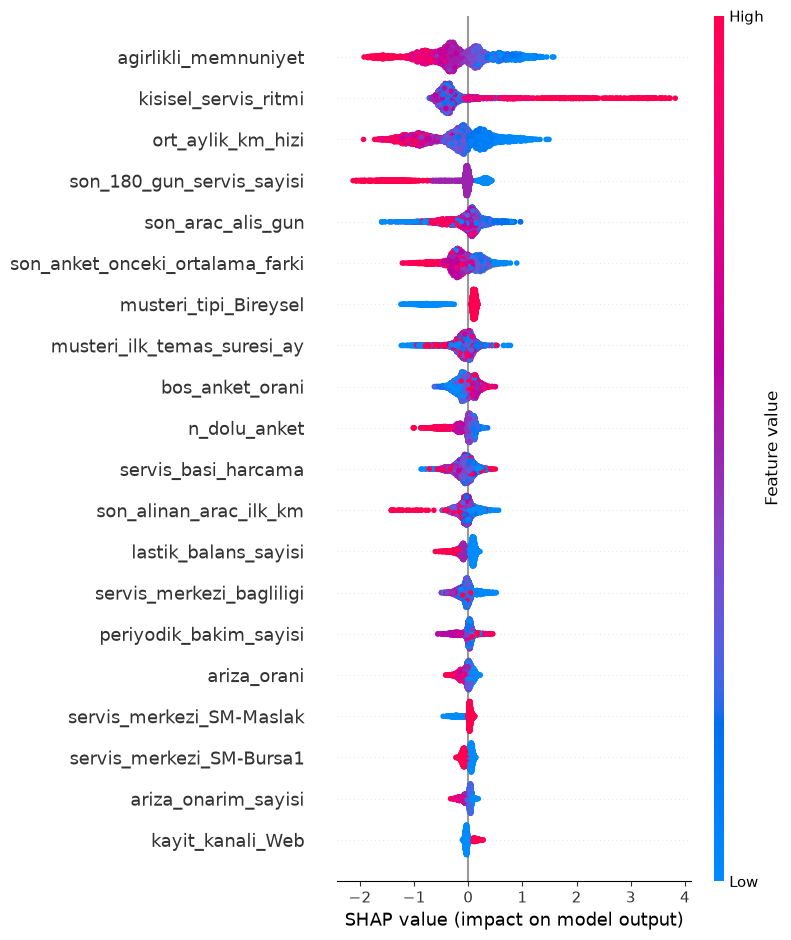

In [30]:
import shap

xgb_model = xgb_final_pipeline.named_steps['model']
# XGBoost NaN değerleri doğrudan ele alır; X'i doldurmadan SHAP'e ver.
X_transformed = X

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(shap_values, X_transformed, feature_names=X.columns)